<a href="https://colab.research.google.com/github/hozaifbinFarid/tiny-payload-wireless-fl/blob/main/Tiny_Payload_Wireless_Federated_Learning_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tiny payloads, informative delivery, and wireless federated learning
**A complete, checkpointed Colab experiment.** This notebook tests a hypothesis; it does not assume the proposed correction improves learning.

**Start:** select a T4 runtime, run all cells, and authorize the optional Google Drive mount. Choose the study with `STUDY_PRESET` in the configuration cell (`har_subjects`, `har_dirichlet` or `pamap2_subjects`). For each study the default `paper` profile creates 216 main runs (12 seeds × 3 payload sizes × 6 methods) and 48 focused robustness runs (24 MLP, 24 correlated-channel). Use `smoke` first for a short end-to-end rehearsal. Run All again after an interruption: completed runs are skipped and partial runs resume.

**Checkpoints:** complete round transactions, model and momentum, all stochastic-stream states, channel state, delivery estimates, validation history, byte/time counters, configuration, dataset identity, and code identity. Three generations and SHA-256 checksums protect recovery. Files use NPZ/JSON, never pickle.

**Compute:** a persistent ledger stops new computation at 9 allocated-GPU wall-clock hours, reserving headroom below the 10-hour allowance. CPU reference execution is supported. The ledger cannot measure Colab time before this notebook starts or shut down an idle GPU after a disconnected browser; check Colab's own usage and disconnect the GPU when finished.

**Outputs:** resumable checkpoints, a frozen run plan, split/data manifests, mathematical checks, gradient-bias diagnostics, validation learning curves, final held-out-subject metrics, paired comparisons, PNG/PDF figures, and a results ZIP.

**Scope:** simulated orthogonal wireless uplinks and public HAR data; no claim of a deployed 6G system, differential privacy, or a faithful reproduction of JCDO/CA-Fed. A fixed-deadline, mean-length baseline isolates the approximation of interest. The strongest fixed-length baseline uses the same importance probabilities as the random-length compressor.


In [ ]:
import os, sys, time, json, math, hashlib, io, zipfile, struct, tempfile
import shutil, platform, importlib.util, subprocess, copy, atexit, warnings
from pathlib import Path
from dataclasses import dataclass, asdict, replace
from collections import defaultdict
from datetime import datetime, timezone

# Set before importing torch. All experiment randomness is generated by NumPy PCG64.
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
missing = [p for p in ('numpy', 'scipy', 'pandas', 'matplotlib')
           if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
import numpy as np
import pandas as pd
import scipy
from scipy import stats, optimize
import matplotlib
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(x):
        print(x.to_string(index=False) if isinstance(x, pd.DataFrame) else x)
    def Markdown(x):
        return x
try:
    import torch
except ImportError:
    torch = None

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Python', platform.python_version(), '| NumPy', np.__version__, '| SciPy', scipy.__version__)


Python 3.13.15 | NumPy 2.1.3 | SciPy 1.16.3


## 1. Controls and persistent storage
Change controls **before** running the rest of the notebook. A changed scientific configuration creates a new experiment identity; the GPU ledger remains shared. `paper` runs the full grid; `smoke` uses real UCI data by default with fewer rounds. `DATA_SOURCE='synthetic'` is an explicit software-test fixture, never a fallback when downloading fails.

`subject_holdout` is the primary protocol: official test subjects remain untouched, three official training subjects supply validation, and the other 18 are federated clients. `within_subject_purged` instead uses all 30 subjects as clients, row-blocks each subject/activity, purges boundaries, and removes detected shared raw half-windows. Its rows have no verified timestamps: it is **not** a certified chronological split. Prefer subject holdout for the primary paper.

Google Drive mounting happens only in Colab. Without it, set `TINYFL_OUTPUT` to a persistent directory; otherwise checkpoints live on ephemeral local disk.


In [ ]:
@dataclass(frozen=True)
class Config:
    profile: str = os.environ.get('TINYFL_PROFILE', 'paper')
    data_source: str = os.environ.get('TINYFL_DATA_SOURCE', 'uci')
    split_protocol: str = os.environ.get('TINYFL_SPLIT', 'subject_holdout')
    mount_drive: bool = os.environ.get('TINYFL_MOUNT_DRIVE', '1') == '1'
    backend: str = os.environ.get('TINYFL_BACKEND', 'auto')  # auto / numpy / torch
    run_experiments: bool = True
    run_diagnostics: bool = True
    final_test: bool = True
    gpu_limit_hours: float = 9.0
    gpu_reservation_seconds: float = 120.0
    max_run_wall_seconds: float = 600.0
    split_seed: int = 20250919
    dirichlet_alpha: float = 0.0
    validation_subjects: int = 3
    purge_windows: int = 2
    rounds: int = 600
    clients_per_round: int = 10
    batch_size: int = 64
    eval_every: int = 25
    checkpoint_every: int = 25
    keep_checkpoints: int = 3
    base_lr: float = 0.01
    momentum: float = 0.0
    weight_decay: float = 0.0
    importance_uniform_mix: float = 0.05
    ema_decay: float = 0.95
    estimated_probability_floor: float = 0.02
    numeric_probability_floor: float = 1e-12
    per_client_bandwidth_hz: float = 100_000.0
    downlink_rate_bps: float = 20_000_000.0
    local_compute_seconds: float = 0.005
    mean_success_target: float = 0.65
    nominal_snr: float = 8.0  # linear, not dB
    channel_persistence: float = 0.90
    probe_rounds: int = 40
    diagnostic_draws: int = 16384
    diagnostic_batches: int = 16
    max_weight_norm: float = 1e6
    strict_backend_resume: bool = True

# Select the study to reproduce (or set the TINYFL_STUDY environment variable).
STUDY_PRESET = os.environ.get('TINYFL_STUDY', 'pamap2_subjects')
STUDY_PRESETS = {
    'har_subjects':    dict(data_source='uci',    clients_per_round=10, validation_subjects=3, dirichlet_alpha=0.0),
    'har_dirichlet':   dict(data_source='uci',    clients_per_round=10, validation_subjects=3, dirichlet_alpha=0.5),
    'pamap2_subjects': dict(data_source='pamap2', clients_per_round=5,  validation_subjects=1, dirichlet_alpha=0.0),
}
if STUDY_PRESET not in STUDY_PRESETS:
    raise ValueError(f'STUDY_PRESET must be one of {sorted(STUDY_PRESETS)}')
CFG = Config(**STUDY_PRESETS[STUDY_PRESET])
if CFG.profile not in {'paper', 'smoke'}:
    raise ValueError('profile must be paper or smoke')
if CFG.profile == 'smoke':
    CFG = replace(CFG, rounds=8, clients_per_round=3, batch_size=8,
                  eval_every=2, checkpoint_every=2, validation_subjects=1,
                  probe_rounds=4, diagnostic_draws=512, diagnostic_batches=4,
                  max_run_wall_seconds=120.0)
assert CFG.data_source in {'uci', 'synthetic', 'pamap2'}
assert CFG.split_protocol in {'subject_holdout', 'within_subject_purged'}
assert 0 < CFG.gpu_limit_hours <= 9.0
assert 0 < CFG.importance_uniform_mix <= 1
assert 0 < CFG.mean_success_target < 1
assert CFG.keep_checkpoints >= 2

IN_COLAB = importlib.util.find_spec('google.colab') is not None if importlib.util.find_spec('google') else False
if IN_COLAB and CFG.mount_drive:
    from google.colab import drive
    drive.mount('/content/drive')
ROOT_NAME = 'TinyPayloadFL_pamap2' if STUDY_PRESET == 'pamap2_subjects' else f'TinyPayloadFL_{STUDY_PRESET}'
default_root = f'/content/drive/MyDrive/{ROOT_NAME}' if IN_COLAB and CFG.mount_drive else f'./{ROOT_NAME}'
ROOT = Path(os.environ.get('TINYFL_OUTPUT', default_root)).expanduser().resolve()
ROOT.mkdir(parents=True, exist_ok=True)
RAW = ROOT / 'data'
RAW.mkdir(exist_ok=True)
GPU_ATTACHED = bool(torch is not None and torch.cuda.is_available())
if CFG.backend == 'torch' and torch is None:
    raise RuntimeError('Torch was requested but is unavailable. Colab supplies it; otherwise choose numpy.')
BACKEND = 'torch' if (CFG.backend == 'torch' or (CFG.backend == 'auto' and GPU_ATTACHED)) else 'numpy'
DEVICE = 'cuda' if BACKEND == 'torch' and GPU_ATTACHED else 'cpu'
if torch is not None:
    torch.set_num_threads(2)
    torch.use_deterministic_algorithms(True)
    if GPU_ATTACHED:
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cudnn.benchmark = False
BACKEND_ID = (f'torch-{torch.__version__}-{DEVICE}-' + (torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'cpu')) if BACKEND == 'torch' else f'numpy-{np.__version__}-cpu'
print('Output:', ROOT, '\nEngine:', BACKEND_ID, '\nProfile:', CFG.profile, '| Data:', CFG.data_source, '| Study:', STUDY_PRESET)
if not (IN_COLAB and CFG.mount_drive) and not os.environ.get('TINYFL_OUTPUT'):
    print('Local output may be ephemeral. Download the final ZIP or choose persistent storage.')


Mounted at /content/drive
Output: /content/drive/MyDrive/TinyPayloadFL_pamap2 
Engine: torch-2.11.0+cu128-cuda-Tesla T4 
Profile: paper | Data: pamap2


## 2. Mathematical contract
Condition on a client's gradient and the observed channel state/history. Write $Z_j\sim\mathrm{Bernoulli}(\pi_j)$ independently, $Q_j=g_jZ_j/\pi_j$, $K=\sum_j Z_j$, and let $L(K)$ include serialization and datagram overhead. Delivery $I$ has probability $p(L)$ and otherwise depends on no update-content information.

With $\bar p=E[p(L)]>0$:
$$E[IQ/\bar p]-g=\operatorname{Cov}(p(L),Q)/\bar p.$$
Consequently
$$\|E[IQ/\bar p]-g\|_2\le\frac{\sqrt{\operatorname{Var}(p(L))\,E\|Q-g\|_2^2}}{\bar p}.$$
These are conditional, elementary identities/bounds, **not claims of a new theorem**. If $p$ is Lipschitz in wire length with constant $C$, the numerator is at most $C\sqrt{\operatorname{Var}(L)E\|Q-g\|^2}$. With linear framing $L=H+bK$, $\operatorname{Var}(L)=b^2\sum_j\pi_j(1-\pi_j)$; segmented framing requires the actual $L(K)$.

The oracle correction obeys $E[IQ/p(L)]=g$ when probabilities are exact and positive, and $E\|IQ/p(L)\|^2=E[\|Q\|^2/p(L)]$. Estimated or clipped probabilities lose this exact guarantee. The notebook does not clip oracle probabilities silently and does not use gradient clipping or error feedback in the primary comparison. FP32 serialization introduces ordinary numerical roundoff.

**Why dimension is insufficient:** uniform retention with expected count $k$ gives $\operatorname{CV}(K)^2=(1-k/d)/k$. Increasing $d$ at fixed $k$ does not make the relative payload fluctuation vanish. Uniform retention can yield scalar shrinkage rather than directional distortion; the main compressor therefore uses magnitude-dependent inclusion probabilities. Fixed-size importance sampling is a crucial control.


In [ ]:
def utc_now():
    return datetime.now(timezone.utc).isoformat()

def json_default(x):
    if isinstance(x, np.ndarray): return x.tolist()
    if isinstance(x, np.generic): return x.item()
    if isinstance(x, Path): return str(x)
    raise TypeError(type(x).__name__)

def canonical(x):
    return json.dumps(x, sort_keys=True, separators=(',', ':'), default=json_default, allow_nan=False)

def digest_obj(x):
    return hashlib.sha256(canonical(x).encode()).hexdigest()

def sha_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1 << 20), b''): h.update(block)
    return h.hexdigest()

def atomic_bytes(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + '.tmp')
    with open(tmp, 'wb') as f:
        f.write(payload); f.flush(); os.fsync(f.fileno())
    os.replace(tmp, path)

def atomic_json(path, obj):
    atomic_bytes(path, (json.dumps(obj, indent=2, default=json_default, allow_nan=False) + '\n').encode())

def atomic_npz(path, **arrays):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + '.tmp')
    with open(tmp, 'wb') as f:
        np.savez_compressed(f, **arrays); f.flush(); os.fsync(f.fileno())
    os.replace(tmp, path)

class BudgetExceeded(RuntimeError):
    pass

class GPUBudget:
    """Conservative pre-reservation ledger. One running notebook per ROOT only."""
    def __init__(self, root, cfg, active):
        self.path = Path(root) / 'gpu_budget.json'
        self.active, self.limit = active, cfg.gpu_limit_hours * 3600
        self.block = cfg.gpu_reservation_seconds
        self.reserved_until = time.monotonic()
        self.session_reserved = 0.0
        self.session_start = self.reserved_until
        if not self.path.exists():
            atomic_json(self.path, {'reserved_seconds': 0.0, 'created': utc_now()})
        if self.active: self.guard()
    def used(self):
        return float(json.loads(self.path.read_text())['reserved_seconds'])
    def guard(self):
        if not self.active: return
        now = time.monotonic()
        if now + 10 < self.reserved_until: return
        overdue = max(0.0, now - self.reserved_until)
        charge = overdue + self.block
        ledger = json.loads(self.path.read_text())
        if ledger['reserved_seconds'] + charge > self.limit:
            raise BudgetExceeded('GPU ledger reached the 9-hour scheduling limit. State will be saved.')
        ledger['reserved_seconds'] += charge
        ledger['updated'] = utc_now()
        atomic_json(self.path, ledger)
        self.session_reserved += charge
        self.reserved_until = max(now, self.reserved_until) + self.block
    def close(self):
        # Only this session's unused final reservation can be returned.
        if self.active and self.session_reserved:
            unused = min(self.session_reserved, max(0.0, self.reserved_until - time.monotonic()))
            ledger = json.loads(self.path.read_text())
            overdue = max(0.0, time.monotonic()-self.reserved_until)
            ledger['reserved_seconds'] = max(0.0, ledger['reserved_seconds'] - unused + overdue)
            ledger['updated'] = utc_now()
            atomic_json(self.path, ledger)
            self.session_reserved = 0.0
        self.active = False

# Re-running this cell in the same kernel settles the prior lease first.
if 'BUDGET' in globals(): BUDGET.close()
BUDGET = GPUBudget(ROOT, CFG, GPU_ATTACHED)
atexit.register(BUDGET.close)


<bound method GPUBudget.close of <__main__.GPUBudget object at 0x7aa4888c9400>>

## 3. Public data, provenance, and split checks
Download from UCI over HTTPS with retries, ZIP CRC validation, and a recorded SHA-256. The modern UCI download can wrap the original ZIP; both layouts are supported. Only needed members are read, without extracting archive paths to disk. No synthetic replacement is used on failure.

The supplied features are already processed by the dataset authors. Additional standardization uses only this experiment's training rows. Its pooled mean/variance can be obtained from federated sufficient statistics; the simulator charges their one-time communication cost equally to all methods. It does not claim stronger privacy guarantees for those statistics.


In [ ]:
UCI_URLS = [
    'https://archive.ics.uci.edu/static/public/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones.zip',
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip',
]

def download_uci(destination):
    import urllib.request
    destination = Path(destination)
    if destination.exists() and zipfile.is_zipfile(destination):
        return destination
    errors = []
    for url in UCI_URLS:
        for attempt in range(2):
            BUDGET.guard()
            tmp = destination.with_suffix('.download')
            try:
                req = urllib.request.Request(url, headers={'User-Agent': 'TinyPayloadFL-research/1.0'})
                with urllib.request.urlopen(req, timeout=60) as response, open(tmp, 'wb') as out:
                    announced = response.headers.get('Content-Length')
                    count = 0
                    while True:
                        chunk = response.read(1 << 20)
                        if not chunk: break
                        count += len(chunk)
                        if count > 250_000_000: raise ValueError('Unexpectedly large download')
                        out.write(chunk)
                        BUDGET.guard()
                if announced and count != int(announced): raise ValueError('Truncated download')
                if not zipfile.is_zipfile(tmp): raise ValueError('Server returned a non-ZIP response')
                with zipfile.ZipFile(tmp) as z:
                    if z.testzip() is not None: raise ValueError('ZIP CRC failure')
                os.replace(tmp, destination)
                atomic_json(destination.with_suffix('.source.json'),
                            {'url': url, 'bytes': count, 'sha256': sha_file(destination), 'retrieved': utc_now()})
                return destination
            except BudgetExceeded:
                raise
            except Exception as e:
                errors.append(f'{url}: {type(e).__name__}: {e}')
                if tmp.exists(): tmp.unlink()
                if attempt == 0: time.sleep(1)
    raise RuntimeError('UCI download failed. Place a valid UCI HAR ZIP at ' + str(destination) + '\n' + '\n'.join(errors))

def read_har_archive(path, need_halves=False):
    outer = zipfile.ZipFile(path)
    nested_buffers, handles = [], [outer]
    z = outer
    for _ in range(3):
        names = z.namelist()
        if any(n.endswith('/train/X_train.txt') or n == 'train/X_train.txt' for n in names): break
        nested = [n for n in names if n.lower().endswith('.zip')]
        if len(nested) != 1: raise ValueError('Cannot identify the HAR ZIP layout')
        buf = io.BytesIO(z.read(nested[0])); nested_buffers.append(buf)
        z = zipfile.ZipFile(buf); handles.append(z)
    else:
        raise ValueError('Unexpected archive nesting')
    def member(suffix):
        names = [n for n in z.namelist() if n.endswith(suffix)]
        if len(names) != 1: raise ValueError('Expected one archive member: ' + suffix)
        return names[0]
    arrays = defaultdict(list)
    try:
        for split in ('train', 'test'):
            for key, fname, dtype in [('X', f'X_{split}.txt', np.float32),
                                      ('y', f'y_{split}.txt', np.int64),
                                      ('subject', f'subject_{split}.txt', np.int64)]:
                with z.open(member(f'{split}/{fname}')) as f:
                    arrays[key].append(np.loadtxt(f, dtype=dtype))
            n = len(arrays['y'][-1])
            arrays['official_test'].append(np.full(n, split == 'test', dtype=bool))
            if need_halves:
                axes = []
                for axis in ('x', 'y', 'z'):
                    with z.open(member(f'{split}/Inertial Signals/total_acc_{axis}_{split}.txt')) as f:
                        axes.append(np.loadtxt(f, dtype=np.float32))
                raw = np.stack(axes, axis=1)
                assert raw.shape == (n, 3, 128)
                halves = np.empty((n, 2), dtype='S32')
                for i in range(n):
                    halves[i, 0] = hashlib.sha256(np.ascontiguousarray(raw[i, :, :64]).tobytes()).hexdigest()[:32].encode()
                    halves[i, 1] = hashlib.sha256(np.ascontiguousarray(raw[i, :, 64:]).tobytes()).hexdigest()[:32].encode()
                arrays['halves'].append(halves)
        out = {key: np.concatenate(value, axis=0) for key, value in arrays.items()}
        out['y'] -= 1
        assert out['X'].shape == (10299, 561), out['X'].shape
        assert len(np.unique(out['subject'])) == 30
        assert np.array_equal(np.unique(out['y']), np.arange(6))
        assert np.isfinite(out['X']).all()
        return out
    finally:
        for handle in reversed(handles): handle.close()

# ── EDIT 1: PAMAP2 download + read functions ──────────────────────────────────

PAMAP2_URL = 'https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip'
PAMAP2_ACTIVITIES = {1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24}  # 12 activities all 9 subjects performed

def download_pamap2(destination):
    import urllib.request
    destination = Path(destination)
    if destination.exists() and zipfile.is_zipfile(destination):
        return destination
    errors = []
    for attempt in range(3):
        BUDGET.guard()
        tmp = destination.with_suffix('.download')
        try:
            req = urllib.request.Request(PAMAP2_URL, headers={'User-Agent': 'TinyPayloadFL-research/1.0'})
            with urllib.request.urlopen(req, timeout=120) as response, open(tmp, 'wb') as out:
                count = 0
                while True:
                    chunk = response.read(1 << 20)
                    if not chunk: break
                    count += len(chunk)
                    if count > 800_000_000: raise ValueError('Unexpectedly large download')
                    out.write(chunk)
                    BUDGET.guard()
            if not zipfile.is_zipfile(tmp): raise ValueError('Not a ZIP')
            os.replace(tmp, destination)
            atomic_json(destination.with_suffix('.source.json'),
                        {'url': PAMAP2_URL, 'bytes': count, 'sha256': sha_file(destination), 'retrieved': utc_now()})
            return destination
        except BudgetExceeded:
            raise
        except Exception as e:
            errors.append(f'attempt {attempt}: {type(e).__name__}: {e}')
            if tmp.exists(): tmp.unlink()
            if attempt < 2: time.sleep(2)
    raise RuntimeError('PAMAP2 download failed.\n' + '\n'.join(errors))

def read_pamap2(path):
    SENSOR_COLS = list(range(3, 54))   # 51 columns: 3 IMUs × 17 measurements, skip heartrate
    WIN, STEP = 256, 128               # 2.56s window, 50% overlap at 100 Hz
    act_map = {a: i for i, a in enumerate(sorted(PAMAP2_ACTIVITIES))}
    X_list, y_list, s_list = [], [], []

    # Handle nested ZIP — outer contains PAMAP2_Dataset.zip
    import io as _io
    with zipfile.ZipFile(path) as outer:
        nested = [n for n in outer.namelist() if n.lower().endswith('.zip')]
        if len(nested) != 1:
            raise ValueError(f'Expected one nested ZIP, found: {nested}')
        inner_buf = _io.BytesIO(outer.read(nested[0]))

    with zipfile.ZipFile(inner_buf) as z:
        all_names = z.namelist()
        for sid in range(1, 10):
            # Find the subject file regardless of exact folder prefix
            matches = [n for n in all_names if f'subject10{sid}.dat' in n and 'Protocol' in n]
            if not matches:
                raise FileNotFoundError(f'subject10{sid}.dat not found in inner ZIP. Available: {all_names[:10]}')
            fname = matches[0]
            with z.open(fname) as f:
                raw = np.genfromtxt(f, dtype=np.float32)   # (T, 54)
            activity_col = raw[:, 1].astype(np.int64)
            keep = np.isin(activity_col, list(PAMAP2_ACTIVITIES))
            raw, activity_col = raw[keep], activity_col[keep]
            sensors = raw[:, SENSOR_COLS]
            nan_rows = ~np.isfinite(sensors).all(axis=1)
            sensors[nan_rows] = 0.0    # impute NaN (rare sensor dropout)
            acts = activity_col
            # Sliding window — extract mean+std per window = 102 features
            n_win = (len(sensors) - WIN) // STEP + 1
            for w in range(n_win):
                sl = sensors[w*STEP : w*STEP + WIN]
                act = acts[w*STEP + WIN//2]    # label from window centre
                if act not in act_map: continue
                feats = np.concatenate([sl.mean(axis=0), sl.std(axis=0)]).astype(np.float32)
                X_list.append(feats)
                y_list.append(act_map[act])
                s_list.append(sid)

    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.int64)
    subject = np.array(s_list, dtype=np.int64)
    # Subjects 8, 9 = official test (mirrors UCI HAR train/test structure)
    official_test = subject >= 8
    assert np.array_equal(np.unique(y), np.arange(len(PAMAP2_ACTIVITIES))), 'Missing activity class'
    return {'X': X, 'y': y, 'subject': subject, 'official_test': official_test}
# ── END EDIT 1 ────────────────────────────────────────────────────────────────

def synthetic_fixture():
    rng = np.random.default_rng(512)
    n_subjects, each, d, c = 8, 72, 12, 3
    centers = rng.normal(size=(c, d)) * 1.5
    xs, ys, ss = [], [], []
    for subject in range(1, n_subjects + 1):
        y = np.tile(np.arange(c), each // c)
        rng.shuffle(y)
        x = centers[y] + rng.normal(scale=.7, size=(each, d)) + rng.normal(scale=.25, size=d)
        xs.append(x); ys.append(y); ss.append(np.full(each, subject))
    out = {'X': np.concatenate(xs).astype(np.float32), 'y': np.concatenate(ys),
           'subject': np.concatenate(ss)}
    out['official_test'] = out['subject'] >= 7
    out['halves'] = np.array([[hashlib.sha256(f'{i}:{j}'.encode()).hexdigest()[:32].encode()
                              for j in range(2)] for i in range(len(out['y']))], dtype='S32')
    return out

def prepare_data(raw, cfg):
    n = len(raw['y']); all_idx = np.arange(n)
    subject, y = raw['subject'], raw['y']
    purge_count = 0
    if cfg.split_protocol == 'subject_holdout':
        candidates = np.unique(subject[~raw['official_test']])
        nv = min(cfg.validation_subjects, len(candidates) - 2)
        valid_subjects = np.random.default_rng(cfg.split_seed).choice(candidates, nv, replace=False)
        test = all_idx[raw['official_test']]
        val = all_idx[np.isin(subject, valid_subjects)]
        train = all_idx[~raw['official_test'] & ~np.isin(subject, valid_subjects)]
        assert not set(subject[train]) & set(subject[val])
        assert not set(subject[train]) & set(subject[test])
        assert not set(subject[val]) & set(subject[test])
    else:
        if 'halves' not in raw: raise ValueError('Raw-window hashes are required for the purged protocol')
        chunks = [[], [], []]
        for s in np.unique(subject):
            for label in np.unique(y):
                ids = all_idx[(subject == s) & (y == label)]
                a, b = int(.6 * len(ids)), int(.8 * len(ids)); gap = cfg.purge_windows
                parts = [ids[:max(0, a-gap)], ids[a+gap:max(a+gap, b-gap)], ids[b+gap:]]
                if any(len(p) == 0 for p in parts):
                    raise ValueError(f'Insufficient purged rows for subject {s}, class {label}; use subject_holdout.')
                for destination, part in zip(chunks, parts): destination.extend(part)
        train, val, test = [np.array(sorted(p), dtype=np.int64) for p in chunks]
        hashes = raw['halves']
        def remove_shared(left, right):
            forbidden = set(hashes[right].ravel().tolist())
            keep = np.array([not any(h in forbidden for h in hashes[i]) for i in left])
            return left[keep]
        val = remove_shared(val, test)
        train = remove_shared(train, np.concatenate([val, test]))
        for a, b in [(train, val), (train, test), (val, test)]:
            assert not set(hashes[a].ravel().tolist()) & set(hashes[b].ravel().tolist())
        purge_count = n - len(train) - len(val) - len(test)
        for s in np.unique(subject):
            if any(not np.any(subject[p] == s) for p in (train, val, test)):
                raise ValueError(f'Purging emptied a subject partition: {s}')
    assert not set(train) & set(val) and not set(train) & set(test) and not set(val) & set(test)
    c = len(np.unique(y)); d = raw['X'].shape[1]
    for ids in (train, val, test):
        assert len(ids) and np.array_equal(np.unique(y[ids]), np.arange(c))
    mean = raw['X'][train].mean(axis=0, dtype=np.float64)
    sd = raw['X'][train].std(axis=0, dtype=np.float64)
    sd[sd < 1e-6] = 1.0
    X = ((raw['X'].astype(np.float64) - mean) / sd).astype(np.float32)

    # ── EDIT 2: Dirichlet non-IID client assignment ───────────────────────────
    if cfg.dirichlet_alpha > 0.0:
        rng_dir = np.random.default_rng(cfg.split_seed + 99991)
        client_ids = np.unique(subject[train])
        clients = {int(s): [] for s in client_ids}
        for cls in np.unique(y[train]):
            cls_idx = train[y[train] == cls].copy()
            rng_dir.shuffle(cls_idx)
            props = rng_dir.dirichlet(np.full(len(client_ids), cfg.dirichlet_alpha))
            cuts = (np.cumsum(props[:-1]) * len(cls_idx)).astype(int)
            for cid, chunk in zip(client_ids, np.split(cls_idx, cuts)):
                if len(chunk): clients[int(cid)].append(chunk)
        clients = {k: np.concatenate(v) for k, v in clients.items() if v}
    else:
        clients = {int(s): train[subject[train] == s] for s in np.unique(subject[train])}
    # ── END EDIT 2 ────────────────────────────────────────────────────────────

    for ids in clients.values(): assert len(ids)
    manifest = {'source': cfg.data_source, 'split_protocol': cfg.split_protocol,
                'split_seed': cfg.split_seed, 'n': n, 'd': d, 'classes': c,
                'dirichlet_alpha': cfg.dirichlet_alpha,
                'training_subjects': sorted(clients), 'validation_subjects': np.unique(subject[val]).tolist(),
                'test_subjects': np.unique(subject[test]).tolist(),
                'train_rows': len(train), 'validation_rows': len(val), 'test_rows': len(test),
                'purged_rows': purge_count, 'feature_bytes': int(X.nbytes),
                'train_index_hash': hashlib.sha256(train.tobytes()).hexdigest(),
                'validation_index_hash': hashlib.sha256(val.tobytes()).hexdigest(),
                'test_index_hash': hashlib.sha256(test.tobytes()).hexdigest(),
                'standardization': 'training rows only; source-supplied feature preprocessing retained'}
    return dict(X=X, y=y, subject=subject, train=train, val=val, test=test,
                mean=mean, sd=sd, clients=clients, d=d, classes=c, manifest=manifest)

BUDGET.guard()

# ── EDIT 3: PAMAP2 data loading branch ───────────────────────────────────────
if CFG.data_source == 'uci':
    archive = download_uci(RAW / 'uci_har.zip')
    source_sha = sha_file(archive)
    raw_data = read_har_archive(archive, CFG.split_protocol == 'within_subject_purged')
elif CFG.data_source == 'pamap2':
    archive = download_pamap2(RAW / 'pamap2.zip')
    source_sha = sha_file(archive)
    raw_data = read_pamap2(archive)
else:
    print('SOFTWARE TEST FIXTURE: synthetic data; these results are not HAR evidence.')
    raw_data = synthetic_fixture()
    source_sha = digest_obj({'fixture': 'synthetic-v1', 'shape': raw_data['X'].shape})
# ── END EDIT 3 ────────────────────────────────────────────────────────────────

DATA = prepare_data(raw_data, CFG)
DATA['manifest']['source_sha256'] = source_sha
DATA_ID = digest_obj(DATA['manifest'])
DATA_CACHE = RAW / f'prepared_{DATA_ID[:16]}.npz'
atomic_npz(DATA_CACHE, X=DATA['X'], y=DATA['y'], subject=DATA['subject'],
           train=DATA['train'], val=DATA['val'], test=DATA['test'], mean=DATA['mean'], sd=DATA['sd'])
atomic_json(DATA_CACHE.with_suffix('.json'), DATA['manifest'])
del raw_data
display(pd.DataFrame([{k: v for k, v in DATA['manifest'].items()
                       if k in ('n', 'd', 'classes', 'train_rows', 'validation_rows', 'test_rows', 'purged_rows')}]))
print('Federated clients:', len(DATA['clients']), '| Prepared feature MB:', DATA['X'].nbytes / 1e6)

,n,d,classes,train_rows,validation_rows,test_rows,purged_rows
0,15164,102,12,11118,1952,2094,0


Federated clients: 6 | Prepared feature MB: 6.186912


## 4. Small models and two numerical engines
Both engines evaluate the same analytic minibatch gradients: multinomial logistic regression or a ReLU MLP. The NumPy engine is a testable CPU reference; the Torch engine runs the same batched matrix operations on T4. No autograd graph or model replica is retained for each client. Gradients/communication stay FP32; mixed precision is intentionally avoided in the unbiasedness experiment.

Finite-difference checks below validate both architectures. When CUDA/Torch is available, an independent Torch-autograd comparison also validates the manually batched gradients. All randomness (initialization, scheduling, minibatches, compression, fading, and probes) has named NumPy streams whose states are checkpointed. There is no hidden stochastic optimizer state.


In [ ]:
class FlatModel:
    def __init__(self, d, classes, architecture='logistic', backend='numpy', device='cpu'):
        self.d, self.classes, self.architecture = d, classes, architecture
        self.widths = [d, classes] if architecture == 'logistic' else [d, 128, 64, classes]
        if architecture not in {'logistic', 'mlp'}: raise ValueError(architecture)
        self.backend, self.device = backend, device
        self.shapes = []
        for a, b in zip(self.widths[:-1], self.widths[1:]): self.shapes.extend([(a, b), (b,)])
        self.sizes = [int(np.prod(s)) for s in self.shapes]
        self.n_parameters = sum(self.sizes)
    def initial(self, seed):
        rng = np.random.default_rng(seed)
        parts = []
        for i, (a, b) in enumerate(zip(self.widths[:-1], self.widths[1:])):
            scale = math.sqrt(2 / a) if i < len(self.widths) - 2 else math.sqrt(1 / a)
            parts.extend([(rng.normal(size=(a, b)) * scale).astype(np.float32).ravel(), np.zeros(b, np.float32)])
        return np.concatenate(parts)
    def unpack(self, flat):
        pieces, start = [], 0
        for shape, size in zip(self.shapes, self.sizes):
            pieces.append(flat[start:start+size].reshape(shape)); start += size
        return pieces
    def gradients(self, flat, x, y):
        """x: clients x batch x features; returns one mean gradient per client."""
        use_torch = self.backend == 'torch'
        if use_torch:
            flat = torch.as_tensor(flat, dtype=torch.float32, device=self.device)
            a = torch.as_tensor(x, dtype=torch.float32, device=self.device)
            labels = torch.as_tensor(y, dtype=torch.long, device=self.device)
        else:
            a = np.asarray(x, dtype=flat.dtype); labels = y
        parts = self.unpack(flat)
        activations, pres = [a], []
        for layer in range(len(self.widths)-1):
            z = a @ parts[2*layer] + parts[2*layer+1]
            pres.append(z)
            if layer < len(self.widths)-2:
                a = torch.clamp_min(z, 0) if use_torch else np.maximum(z, 0)
            else: a = z
            activations.append(a)
        if use_torch:
            p = torch.softmax(a, dim=-1)
            losses = -torch.log_softmax(a, dim=-1).gather(-1, labels[..., None]).squeeze(-1).mean(dim=1)
            delta = p.clone()
            delta.scatter_add_(-1, labels[..., None], -torch.ones_like(labels[..., None], dtype=p.dtype))
        else:
            z = a - a.max(axis=-1, keepdims=True)
            logp = z - np.log(np.exp(z).sum(axis=-1, keepdims=True))
            p = np.exp(logp)
            losses = -np.take_along_axis(logp, labels[..., None], axis=-1)[..., 0].mean(axis=1)
            delta = p.copy()
            np.put_along_axis(delta, labels[..., None],
                              np.take_along_axis(delta, labels[..., None], axis=-1)-1, axis=-1)
        delta = delta / x.shape[1]
        gradients = [None] * len(parts)
        for layer in reversed(range(len(self.widths)-1)):
            dw = (torch.einsum('cbi,cbj->cij', activations[layer], delta) if use_torch
                  else np.einsum('cbi,cbj->cij', activations[layer], delta))
            db = delta.sum(dim=1) if use_torch else delta.sum(axis=1)
            gradients[2*layer] = dw.reshape(x.shape[0], -1)
            gradients[2*layer+1] = db.reshape(x.shape[0], -1)
            if layer:
                delta = (delta @ parts[2*layer].T) * (pres[layer-1] > 0)
        if use_torch:
            return torch.cat(gradients, dim=1).cpu().numpy(), losses.cpu().numpy()
        return np.concatenate(gradients, axis=1), losses
    def logits(self, flat, x):
        # Small evaluation sets are evaluated on CPU to avoid retaining GPU arrays.
        a = np.asarray(x, dtype=np.float32)
        parts = self.unpack(np.asarray(flat, dtype=np.float32))
        for layer in range(len(self.widths)-1):
            a = a @ parts[2*layer] + parts[2*layer+1]
            if layer < len(self.widths)-2: a = np.maximum(a, 0)
        return a

def evaluate(model, flat, data, partition='val'):
    ids = data[partition]
    labels = data['y'][ids]
    logits = model.logits(flat, data['X'][ids])
    shifted = logits - logits.max(axis=1, keepdims=True)
    logp = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    pred = logits.argmax(axis=1)
    correct = pred == labels
    per_subject = {str(int(s)): float(correct[data['subject'][ids] == s].mean())
                   for s in np.unique(data['subject'][ids])}
    confusion = np.zeros((data['classes'], data['classes']), np.int64)
    np.add.at(confusion, (labels, pred), 1)
    recalls = np.divide(confusion.diagonal(), confusion.sum(axis=1),
                        out=np.zeros(data['classes']), where=confusion.sum(axis=1)>0)
    return {'loss': float(-logp[np.arange(len(ids)), labels].mean()),
            'accuracy': float(correct.mean()), 'balanced_accuracy': float(recalls.mean()),
            'worst_subject_accuracy': min(per_subject.values()),
            'per_subject': per_subject, 'confusion': confusion.tolist()}

assert FlatModel(561, 6).n_parameters == 3372
assert FlatModel(561, 6, 'mlp').n_parameters == 80582
print('Planned parameter counts:', {'logistic': 3372, 'mlp': 80582})


Planned parameter counts: {'logistic': 3372, 'mlp': 80582}


## 5. Unbiased compressors and real serialization
Random-length importance sampling uses independent Bernoulli coordinates with $\pi_j=\min(1,c\,s_j)$ and $\sum_j\pi_j=k$. Scores mix gradient magnitude with a small uniform component so every coordinate has positive inclusion probability.

The `fixed_k` control uses systematic probability-proportional-to-size sampling: a uniform offset on a cumulative inclusion-probability axis selects exactly $k$ distinct coordinates, with the **same marginal $\pi_j$**. A random coordinate permutation removes any favorable dependence on parameter order. `uniform_fixed_k` is also implemented for an optional sensitivity run. No error-feedback accumulator is used.

Every chosen coordinate is serialized as uint32 index + float32 value, including chosen zero values. A 16-byte application header and 8-byte segmentation header are used. Each modeled IPv6/UDP datagram contributes another 48 bytes; MTU is 1280 bytes. `wire_bytes` therefore counts complete logical attempted datagrams. PHY coding, symbols, energy and independent fragment loss are outside this abstraction. Delivery is an all-or-none block-outage event for the entire update; there are no retransmissions.


In [ ]:
MTU, IP_UDP_BYTES, SEGMENT_BYTES = 1280, 48, 8
APP_HEADER_BYTES, ENTRY_BYTES = 16, 8
CHUNK_BYTES = MTU - IP_UDP_BYTES - SEGMENT_BYTES

def framed_bytes(message_bytes):
    size = np.asarray(message_bytes)
    return size + np.maximum(1, np.ceil(size / CHUNK_BYTES)) * (IP_UDP_BYTES + SEGMENT_BYTES)

def wire_bytes_for_count(count):
    return framed_bytes(APP_HEADER_BYTES + ENTRY_BYTES * np.asarray(count))

def serialize_update(indices, values, dimension, round_id):
    indices = np.asarray(indices, dtype='<u4')
    values = np.asarray(values, dtype='<f4')
    if len(indices) != len(values) or len(np.unique(indices)) != len(indices):
        raise ValueError('Invalid sparse update indices')
    if len(indices) and int(indices.max()) >= dimension: raise ValueError('Index outside model')
    records = np.empty(len(indices), dtype=[('index', '<u4'), ('value', '<f4')])
    records['index'], records['value'] = indices, values
    message = struct.pack('<4sIII', b'TPFL', int(round_id), int(dimension), len(indices)) + records.tobytes()
    count = max(1, math.ceil(len(message)/CHUNK_BYTES))
    packets = [struct.pack('<IHH', int(round_id), i, count) + message[i*CHUNK_BYTES:(i+1)*CHUNK_BYTES]
               for i in range(count)]
    size = sum(len(p)+IP_UDP_BYTES for p in packets)
    assert size == int(wire_bytes_for_count(len(indices)))
    assert all(len(p)+IP_UDP_BYTES <= MTU for p in packets)
    return packets, size

def deserialize_update(packets):
    parts, identifier, expected = {}, None, None
    for packet in packets:
        rid, index, total = struct.unpack('<IHH', packet[:8])
        if identifier is None: identifier, expected = rid, total
        if rid != identifier or total != expected or index in parts: raise ValueError('Inconsistent fragments')
        parts[index] = packet[8:]
    if expected is None or set(parts) != set(range(expected)): raise ValueError('Missing fragment')
    message = b''.join(parts[i] for i in range(expected))
    magic, rid, dimension, count = struct.unpack('<4sIII', message[:16])
    if magic != b'TPFL' or rid != identifier or len(message) != 16+8*count: raise ValueError('Invalid update framing')
    records = np.frombuffer(message[16:], dtype=[('index', '<u4'), ('value', '<f4')])
    if len(records) and int(records['index'].max()) >= dimension: raise ValueError('Corrupt sparse index')
    return dimension, rid, records['index'].copy(), records['value'].copy()

def inclusion_probabilities(gradient, k, mix=0.05):
    g = np.asarray(gradient, np.float64)
    d = len(g)
    if not 1 <= k <= d: raise ValueError(f'k={k} outside [1,{d}]')
    if k == d: return np.ones(d)
    magnitude = np.abs(g)
    scores = (1-mix)*magnitude/max(magnitude.sum(), np.finfo(float).tiny) + mix/d
    scores /= scores.sum()
    probabilities = np.zeros(d)
    active = np.ones(d, dtype=bool)
    remaining = float(k)
    while True:
        scaled = scores[active] * remaining / scores[active].sum()
        saturated = scaled >= 1.0
        ids = np.flatnonzero(active)
        if not saturated.any():
            probabilities[ids] = scaled
            break
        probabilities[ids[saturated]] = 1.0
        active[ids[saturated]] = False
        remaining -= int(saturated.sum())
        if not active.any(): break
    if not np.isclose(probabilities.sum(), k, rtol=0, atol=1e-8): raise ArithmeticError('Wrong expected payload')
    if np.any(probabilities <= 0) or np.any(probabilities > 1+1e-10): raise ArithmeticError('Invalid inclusion probability')
    return np.minimum(probabilities, 1.0)

def systematic_indices(probabilities, rng):
    pi = np.asarray(probabilities, np.float64)
    k = int(round(pi.sum()))
    if abs(pi.sum()-k) > 1e-7: raise ValueError('Systematic sampling needs an integer expected count')
    order = rng.permutation(len(pi))
    cumulative = np.cumsum(pi[order])
    cumulative[-1] = float(k)
    thresholds = rng.random() + np.arange(k)
    chosen = order[np.searchsorted(cumulative, thresholds, side='right')]
    if len(np.unique(chosen)) != k: raise ArithmeticError('Systematic sample duplicated a coordinate')
    return np.sort(chosen)

def compress_gradient(g, k, rng, method, mix):
    pi = (np.full(len(g), k/len(g)) if method == 'uniform_fixed_k'
          else inclusion_probabilities(g, k, mix))
    if method in {'fixed_k', 'uniform_fixed_k'}:
        indices = systematic_indices(pi, rng)
    else:
        indices = np.flatnonzero(rng.random(len(g)) < pi)
    values = (np.asarray(g, np.float64)[indices] / pi[indices]).astype(np.float32)
    return indices, values, pi


## 6. Observable-state Rayleigh channel and charged probability calibration
Per-client OFDMA bandwidth is fixed. At a round boundary, clients have an observed slow state (good/bad). It is independent across rounds in `iid`, or a symmetric two-state Markov chain in `markov`. Conditional on that state, fast Rayleigh block fading is independent of the compressor. With linear mean SNR $s$ and uplink deadline $T$:
$$p(L\mid s)=\exp\left[-\frac{2^{8L/(BT)}-1}{s}\right].$$
The deadline is fixed **within a run**, chosen from the reference count $k$ and a nominal success target. Across payload-size experiments it changes to hold normalized load approximately comparable; these are different operating points, and their actual slot lengths are reported.

The oracle knows the conditional channel curve. The practical estimate fits only its SNR parameter from separately scheduled, length-labelled probe packets. Probe payloads and control messages are charged, as is the entire calibration slot duration. Both slow states are sampled by a separate calibration Markov process. A regularized maximum-likelihood fit is deliberately reported as **estimated**, not exact; a configurable probability floor introduces explicit bias. Oracle baselines are privileged reference curves, not deployable methods with free channel estimation.

Every training round also charges a reliable full-model broadcast, reliable observed-state control messages and modeled local compute time. Setup sufficient-statistic uploads/normalizer broadcast are charged once. Reliable control/downlink and their nominal rates are modeling assumptions. Report both uplink-only and total communication. Simulated time is distinct from notebook/GPU wall time.


In [ ]:
STATE_MULTIPLIERS = np.array([0.5, 1.6])
CONTROL_WIRE_BYTES = int(framed_bytes(1))

def deadline_for_k(k, cfg):
    spectral = math.log2(1-cfg.nominal_snr*math.log(cfg.mean_success_target))
    return float(8*wire_bytes_for_count(k)/(cfg.per_client_bandwidth_hz*spectral))

def delivery_probability(length, snr, deadline, cfg):
    exponent = 8*np.asarray(length, np.float64)/(cfg.per_client_bandwidth_hz*deadline)
    with np.errstate(over='ignore', under='ignore'):
        threshold = np.expm1(np.minimum(exponent, 1024)*math.log(2))
        p = np.exp(-threshold/np.asarray(snr, np.float64))
    return np.asarray(p)

def advance_channel(previous, mode, rng, cfg):
    if mode == 'iid': return rng.integers(0, 2, size=len(previous), dtype=np.int8)
    if mode != 'markov': raise ValueError(mode)
    return np.bitwise_xor(previous, (rng.random(len(previous)) > cfg.channel_persistence).astype(np.int8))

def link_means(n, seed, cfg):
    means = cfg.nominal_snr*np.exp(np.linspace(-.35, .35, n))
    np.random.default_rng(seed + 9041).shuffle(means)
    return means

def fit_probe_curve(lengths, outcomes, deadline, cfg):
    if not len(outcomes): return cfg.nominal_snr
    lengths, outcomes = np.asarray(lengths), np.asarray(outcomes)
    def objective(log_snr):
        p = delivery_probability(lengths, math.exp(log_snr), deadline, cfg)
        p = np.clip(p, 1e-12, 1-1e-12)  # likelihood numerics, not oracle aggregation
        penalty = .5*((log_snr-math.log(cfg.nominal_snr))/1.5)**2
        return float(-np.sum(outcomes*np.log(p)+(1-outcomes)*np.log1p(-p)) + penalty)
    fit = optimize.minimize_scalar(objective, bounds=(math.log(.05), math.log(500)), method='bounded')
    if not fit.success: raise RuntimeError('Probe likelihood optimization failed')
    return float(math.exp(fit.x))

def calibrate_links(n, means, k, mode, seed, cfg):
    rng = np.random.default_rng(seed+60817)
    state = rng.integers(0, 2, size=n, dtype=np.int8)
    records, uplink, seconds = [], 0, 0.0
    deadline = deadline_for_k(k, cfg)
    for r in range(cfg.probe_rounds):
        BUDGET.guard()
        state = advance_channel(state, mode, rng, cfg)
        for client in range(n):
            count = max(1, int(round(k*rng.choice([.5, .8, 1., 1.4, 1.8]))))
            length = int(wire_bytes_for_count(count))
            p = float(delivery_probability(length, means[client]*STATE_MULTIPLIERS[state[client]], deadline, cfg))
            success = int(rng.random() < p)
            records.append({'client': client, 'state': int(state[client]), 'round': r,
                            'length': length, 'success': success, 'holdout': r % 5 == 4})
            uplink += length+CONTROL_WIRE_BYTES
        seconds += deadline + 8*CONTROL_WIRE_BYTES/(cfg.per_client_bandwidth_hz*math.log2(1+cfg.nominal_snr))
    estimated = np.full((n, 2), cfg.nominal_snr)
    for client in range(n):
        for state_id in range(2):
            selected = [x for x in records if x['client'] == client and x['state'] == state_id and not x['holdout']]
            estimated[client, state_id] = fit_probe_curve([x['length'] for x in selected],
                                                          [x['success'] for x in selected], deadline, cfg)
    held = [x for x in records if x['holdout']]
    predicted = [float(delivery_probability(x['length'], estimated[x['client'], x['state']], deadline, cfg)) for x in held]
    brier = float(np.mean([(p-x['success'])**2 for p, x in zip(predicted, held)])) if held else None
    return {'estimated_snr': estimated, 'uplink_bytes': uplink, 'sim_seconds': seconds,
            'records': records, 'heldout_brier': brier}

METHODS = ('naive', 'mean_length', 'client_ema', 'conditional', 'estimated_conditional', 'fixed_k')
METHOD_LABELS = {
    'naive': 'Uncorrected dropped updates',
    'mean_length': 'Oracle channel at mean count',
    'client_ema': 'Past-delivery EMA (heuristic)',
    'conditional': 'Oracle length-conditioned IPW',
    'estimated_conditional': 'Probe-estimated IPW (floored)',
    'fixed_k': 'Fixed-size importance + channel IPW',
    'uniform_fixed_k': 'Fixed-size uniform + channel IPW',
    'clipped_conditional': 'Oracle IPW with explicit clipping',
}


## 7. Executable correctness checks
These checks are designed to fail on substantive implementation errors: analytic gradients, compression marginals, exact expectation identities, fragment reconstruction, and fixed-size sampling. They are not performance evidence. The tiny exact counterexample integrates over **all** masks and delivery outcomes analytically.


In [ ]:
def exact_counterexample():
    g, pi = np.array([1., 4., -2.]), np.array([.2, .8, .4])
    masks = np.array([[int(v) for v in f'{i:03b}'] for i in range(8)])
    mass = np.prod(np.where(masks, pi, 1-pi), axis=1)
    q = masks*g/pi
    p = np.exp(-.8*masks.sum(axis=1))
    pbar = float(mass@p)
    compressed = mass@q
    marginal = (mass*p)@q/pbar
    corrected = mass@q  # sum_I E[I Q/p | Q] = Q
    covariance = (mass*(p-pbar))@(q-g)
    var_p = float(mass@(p-pbar)**2)
    mse_q = float(mass@np.sum((q-g)**2, axis=1))
    assert np.allclose(compressed, g, atol=1e-12)
    assert np.allclose(marginal-g, covariance/pbar, atol=1e-12)
    assert np.allclose(corrected, g, atol=1e-12)
    assert np.linalg.norm(marginal-g) <= math.sqrt(var_p*mse_q)/pbar + 1e-12
    assert np.linalg.norm(marginal-g) > .01
    return pd.DataFrame({'coordinate': np.arange(3), 'true_gradient': g,
                         'average_probability_weighting': marginal, 'conditional_weighting': corrected})

def mathematical_checks():
    rng = np.random.default_rng(99)
    checked = []
    for architecture in ('logistic', 'mlp'):
        model = FlatModel(4, 3, architecture)
        w = model.initial(42).astype(np.float64)
        x = rng.normal(size=(2, 5, 4)); y = rng.integers(0, 3, size=(2, 5))
        analytic, _ = model.gradients(w, x, y)
        # Float64 central differences; reject near-zero ReLU crossings by small epsilon.
        ids = rng.choice(len(w), min(30, len(w)), replace=False)
        for j in ids:
            plus, minus = w.copy(), w.copy(); eps = 1e-6
            plus[j] += eps; minus[j] -= eps
            fd = (model.gradients(plus, x, y)[1] - model.gradients(minus, x, y)[1])/(2*eps)
            if not np.allclose(fd, analytic[:, j], atol=2e-6, rtol=2e-4):
                raise AssertionError(f'Gradient check failed: {architecture}, coordinate {j}')
        if torch is not None:
            engine = FlatModel(4, 3, architecture, 'torch', 'cuda' if GPU_ATTACHED else 'cpu')
            actual, _ = engine.gradients(w.astype(np.float32), x.astype(np.float32), y)
            assert np.allclose(actual, analytic, atol=2e-5, rtol=2e-4)
            wt = torch.tensor(w, dtype=torch.float64, requires_grad=True)
            a = torch.tensor(x[0], dtype=torch.float64)
            parts = model.unpack(wt)
            for layer in range(len(model.widths)-1):
                a = a@parts[2*layer]+parts[2*layer+1]
                if layer < len(model.widths)-2: a = torch.relu(a)
            loss = torch.nn.functional.cross_entropy(a, torch.tensor(y[0]))
            auto = torch.autograd.grad(loss, wt)[0].detach().numpy()
            assert np.allclose(auto, analytic[0], atol=1e-9, rtol=1e-7)
        checked.append(architecture+' gradients')
    gradient = np.array([0., .1, -2., 4., .2, 1., -3.])
    pi = inclusion_probabilities(gradient, 3, .05)
    assert np.isclose(pi.sum(), 3)
    totals = np.zeros(len(pi)); draws = 12000
    for _ in range(draws):
        ids = systematic_indices(pi, rng)
        assert len(ids) == 3
        totals[ids] += 1
    se = np.sqrt(pi*(1-pi)/draws)
    assert np.all(np.abs(totals/draws-pi) <= 6*se+.002)
    for count in (0, 1, 128, 512):
        ids = np.arange(count, dtype=np.uint32); values = rng.normal(size=count).astype(np.float32)
        packets, size = serialize_update(ids, values, max(count, 1), 17)
        dim, rid, decoded_ids, decoded = deserialize_update(packets[::-1])
        assert rid == 17 and np.array_equal(ids, decoded_ids) and np.array_equal(values, decoded)
        assert size == wire_bytes_for_count(count)
    table = exact_counterexample()
    checked += ['fixed-size inclusion marginals', 'packet serialization', 'exact covariance/correction identities']
    print('PASS:', '; '.join(checked))
    return table

EXACT_TABLE = mathematical_checks()
display(EXACT_TABLE)


PASS: logistic gradients; mlp gradients; fixed-size inclusion marginals; packet serialization; exact covariance/correction identities


,coordinate,true_gradient,average_probability_weighting,conditional_weighting
0,0,1.0,0.504940,1.0
1,1,4.0,3.212572,4.0
2,2,-2.0,-1.152522,-2.0


## 8. Transactional checkpoints and the federated trainer
The objective weights a client by its training-set size. Clients are sampled uniformly without replacement, with inclusion probability $q=m/C$. Aggregation uses $\sum_{i\in S}(n_i/N)I_iQ_i/(q\,p_i)$ for the corrected methods. Dropped updates are zero; the denominator is **not** renormalized over successful clients.

A round is a pure state transition: model, RNGs, channel, estimates, costs and history are committed together only after the round finishes. Interrupting halfway through a round saves the preceding committed state, allowing an identical replay. A checksum failure falls back to an earlier valid generation. Resume requires the same data, scientific configuration, implementation fingerprint and (by default) numerical backend.

Learning rates and evaluation frequency are fixed before the test set is opened. `client_ema` uses probabilities from **previous** rounds. The exact conditional and fixed-size controls raise on numerically unresolvable probabilities; the estimated method floors probabilities explicitly and records how often it does so. No method gets an automatic learning-rate rescue after diverging.


In [ ]:
RNG_NAMES = ('schedule', 'minibatch', 'compression', 'channel')
STATE_ARRAYS = ('w', 'velocity', 'best_w', 'ema', 'channel', 'means', 'estimated_snr')

def new_rng_states(seed):
    states = {}
    for name in RNG_NAMES:
        value = int(hashlib.sha256(f'{seed}:{name}'.encode()).hexdigest()[:16], 16)
        states[name] = np.random.default_rng(value).bit_generator.state
    return states

def restore_rngs(states):
    rngs = {}
    for name, state in states.items():
        rng = np.random.default_rng()
        rng.bit_generator.state = copy.deepcopy(state)
        rngs[name] = rng
    return rngs

def scientific_config(cfg):
    ignored = {'mount_drive', 'backend', 'run_experiments', 'run_diagnostics', 'final_test',
               'gpu_limit_hours', 'gpu_reservation_seconds', 'max_run_wall_seconds',
               'keep_checkpoints', 'strict_backend_resume', 'diagnostic_draws', 'diagnostic_batches'}
    return {k: v for k, v in asdict(cfg).items() if k not in ignored}

def save_checkpoint(folder, state, cfg):
    folder = Path(folder); folder.mkdir(parents=True, exist_ok=True)
    path = folder / f'state_{int(state["round"]):06d}.npz'
    metadata = {key: value for key, value in state.items() if key not in STATE_ARRAYS}
    arrays = {key: np.asarray(state[key]) for key in STATE_ARRAYS}
    arrays['metadata_json'] = np.array(canonical(metadata))
    atomic_npz(path, **arrays)
    checksum = sha_file(path)
    atomic_json(path.with_suffix('.sha256.json'), {'sha256': checksum})
    atomic_json(folder / 'latest.json', {'file': path.name, 'sha256': checksum, 'round': state['round']})
    # Delete only old generations created by this checkpoint writer.
    for old in sorted(folder.glob('state_*.npz'))[:-cfg.keep_checkpoints]:
        old.unlink()
        sidecar = old.with_suffix('.sha256.json')
        if sidecar.exists(): sidecar.unlink()
    return path

def load_checkpoint(folder, identity, cfg):
    folder = Path(folder)
    candidates = sorted(folder.glob('state_*.npz'), reverse=True)
    if not candidates: return None
    failures = []
    for path in candidates:
        try:
            checksum = json.loads(path.with_suffix('.sha256.json').read_text())['sha256']
            if sha_file(path) != checksum: raise ValueError('Checksum mismatch')
            with np.load(path, allow_pickle=False) as blob:
                state = json.loads(str(blob['metadata_json'].item()))
                if state['identity'] != identity: raise RuntimeError('Checkpoint identity does not match')
                if cfg.strict_backend_resume and state['backend_id'] != BACKEND_ID:
                    raise RuntimeError('Numerical backend changed; use a new study or explicitly disable strict backend resume')
                state.update({key: blob[key].copy() for key in STATE_ARRAYS})
            if failures: print('Recovered earlier checkpoint:', path.name, '| rejected:', '; '.join(failures))
            return state
        except RuntimeError:
            raise
        except Exception as e:
            failures.append(f'{path.name}: {type(e).__name__}: {e}')
    raise RuntimeError('No valid checkpoint generation. Files were preserved. ' + '; '.join(failures))

def zero_meters():
    return {k: 0.0 for k in ('uplink_bytes', 'downlink_bytes', 'probe_uplink_bytes',
                             'control_uplink_bytes', 'gradient_uplink_bytes', 'delivered_gradient_bytes',
                             'sim_seconds', 'compute_wall_seconds', 'attempts', 'deliveries',
                             'entries_attempted', 'entries_delivered', 'probabilities_floored')}

def initial_state(spec, data, cfg, identity, folder):
    model = FlatModel(data['d'], data['classes'], spec['model'], BACKEND, DEVICE)
    w = model.initial(spec['seed'])
    n = len(data['clients'])
    means = link_means(n, spec['seed'], cfg)
    estimated_snr = np.full((n, 2), cfg.nominal_snr)
    meters = zero_meters()
    # Reliable setup: upload count/sum/sum-of-squares; broadcast mean and scale.
    setup_up = n*float(framed_bytes(16 + (2*data['d']+1)*8))
    setup_down = float(framed_bytes(16+2*data['d']*4))
    meters['uplink_bytes'], meters['downlink_bytes'] = setup_up, setup_down
    nominal_rate = cfg.per_client_bandwidth_hz*math.log2(1+cfg.nominal_snr)
    meters['sim_seconds'] = 8*(setup_up/n)/nominal_rate + 8*setup_down/cfg.downlink_rate_bps
    calibration_summary = None
    if spec['method'] == 'estimated_conditional':
        calibration_file = Path(folder) / 'probe_calibration.json'
        if calibration_file.exists():
            calibration = json.loads(calibration_file.read_text())
            if calibration.get('identity') != identity: raise RuntimeError('Wrong calibration identity')
            estimated_snr = np.array(calibration['estimated_snr'])
        else:
            calibration = calibrate_links(n, means, spec['k'], spec['channel'], spec['seed'], cfg)
            calibration['identity'] = identity
            atomic_json(calibration_file, calibration)
            estimated_snr = np.array(calibration['estimated_snr'])
        meters['uplink_bytes'] += calibration['uplink_bytes']
        meters['probe_uplink_bytes'] = float(calibration['uplink_bytes'])
        meters['sim_seconds'] += calibration['sim_seconds']
        calibration_summary = {'heldout_brier': calibration['heldout_brier'],
                               'probe_count': len(calibration['records'])}
    rng_states = new_rng_states(spec['seed'])
    # Initial state is common across methods; the first transition draws the first observed state.
    channel = np.random.default_rng(spec['seed']+87).integers(0, 2, size=n, dtype=np.int8)
    initial_val = evaluate(model, w, data, 'val')
    history = [{'round': 0, 'val_loss': initial_val['loss'], 'val_accuracy': initial_val['accuracy'],
                'val_worst_subject': initial_val['worst_subject_accuracy'],
                'total_wire_bytes': meters['uplink_bytes']+meters['downlink_bytes'],
                'uplink_bytes': meters['uplink_bytes'], 'sim_seconds': meters['sim_seconds']}]
    return {'identity': identity, 'spec': spec, 'science_config': scientific_config(cfg),
            'backend_id': BACKEND_ID, 'round': 0, 'status': 'running', 'created': utc_now(),
            'w': w, 'velocity': np.zeros_like(w), 'best_w': w.copy(),
            'best_val_loss': initial_val['loss'], 'best_round': 0,
            'ema': np.full(n, cfg.mean_success_target), 'channel': channel, 'means': means,
            'estimated_snr': estimated_snr, 'rng': rng_states, 'meters': meters,
            'history': history, 'calibration_summary': calibration_summary,
            'deadline_seconds': deadline_for_k(spec['k'], cfg), 'error': None}

def round_step(state, data, cfg, model):
    start = time.monotonic()
    BUDGET.guard()
    spec, k, method = state['spec'], state['spec']['k'], state['spec']['method']
    rngs = restore_rngs(state['rng'])
    client_ids = np.array(sorted(data['clients']))
    count = len(client_ids); m = min(cfg.clients_per_round, count)
    chosen = rngs['schedule'].choice(count, m, replace=False)
    batch_ids = np.stack([rngs['minibatch'].choice(data['clients'][int(client_ids[i])], cfg.batch_size, replace=True)
                          for i in chosen])
    gradients, losses = model.gradients(state['w'], data['X'][batch_ids], data['y'][batch_ids])
    if not np.isfinite(gradients).all() or not np.isfinite(losses).all():
        raise FloatingPointError('Nonfinite local gradient/loss')
    channel = advance_channel(state['channel'], spec['channel'], rngs['channel'], cfg)
    fading_uniforms = rngs['channel'].random(count)  # consume for all clients regardless of method
    aggregate = np.zeros(model.n_parameters, np.float64)
    ema = state['ema'].copy()
    meters = state['meters'].copy()
    maximum_weight, minimum_p, floor_count = 0.0, 1.0, 0
    for batch_index, client in enumerate(chosen):
        g = gradients[batch_index]
        indices, values, pi = compress_gradient(g, k, rngs['compression'], method, cfg.importance_uniform_mix)
        packets, length = serialize_update(indices, values, model.n_parameters, state['round']+1)
        # Decode exactly what the receiver would get, including FP32 rounding.
        _, _, indices, values = deserialize_update(packets)
        snr = state['means'][client]*STATE_MULTIPLIERS[channel[client]]
        actual_p = float(delivery_probability(length, snr, state['deadline_seconds'], cfg))
        minimum_p = min(minimum_p, actual_p)
        delivered = bool(fading_uniforms[client] < actual_p)
        if method == 'naive': denominator = 1.0
        elif method == 'mean_length':
            denominator = float(delivery_probability(wire_bytes_for_count(pi.sum()), snr, state['deadline_seconds'], cfg))
        elif method == 'client_ema': denominator = max(float(state['ema'][client]), cfg.estimated_probability_floor)
        elif method == 'estimated_conditional':
            raw_p = float(delivery_probability(length, state['estimated_snr'][client, channel[client]], state['deadline_seconds'], cfg))
            denominator = max(raw_p, cfg.estimated_probability_floor)
            floor_count += int(raw_p < cfg.estimated_probability_floor)
        elif method == 'clipped_conditional':
            denominator = max(actual_p, cfg.estimated_probability_floor)
            floor_count += int(actual_p < cfg.estimated_probability_floor)
        elif method in {'conditional', 'fixed_k', 'uniform_fixed_k'}: denominator = actual_p
        else: raise ValueError(method)
        if denominator < cfg.numeric_probability_floor or not math.isfinite(denominator):
            raise FloatingPointError('IPW probability is numerically unsafe; no silent oracle clipping applied')
        maximum_weight = max(maximum_weight, 1/denominator)
        client_mass = len(data['clients'][int(client_ids[client])])/len(data['train'])
        if delivered:
            aggregate[indices] += values.astype(np.float64)*client_mass/(m/count)/denominator
        ema[client] = cfg.ema_decay*state['ema'][client]+(1-cfg.ema_decay)*float(delivered)
        meters['gradient_uplink_bytes'] += length
        meters['uplink_bytes'] += length+CONTROL_WIRE_BYTES
        meters['control_uplink_bytes'] += CONTROL_WIRE_BYTES
        meters['delivered_gradient_bytes'] += length*int(delivered)
        meters['attempts'] += 1; meters['deliveries'] += int(delivered)
        meters['entries_attempted'] += len(indices)
        meters['entries_delivered'] += len(indices)*int(delivered)
    meters['probabilities_floored'] += floor_count
    # Weight decay defaults to zero and is applied identically after aggregation if enabled.
    aggregate += cfg.weight_decay*state['w']
    velocity = (cfg.momentum*state['velocity']+aggregate).astype(np.float32)
    lr = cfg.base_lr*math.sqrt(k/128)
    w = (state['w']-lr*velocity).astype(np.float32)
    if not np.isfinite(w).all() or np.linalg.norm(w.astype(np.float64)) > cfg.max_weight_norm:
        raise FloatingPointError('Model diverged; retain and report the failure instead of changing the learning rate')
    downlink = float(framed_bytes(16+4*model.n_parameters))
    meters['downlink_bytes'] += downlink
    nominal_rate = cfg.per_client_bandwidth_hz*math.log2(1+cfg.nominal_snr)
    meters['sim_seconds'] += (8*downlink/cfg.downlink_rate_bps + cfg.local_compute_seconds
                             + 8*CONTROL_WIRE_BYTES/nominal_rate + state['deadline_seconds'])
    r = state['round']+1
    out = {**state, 'round': r, 'w': w, 'velocity': velocity, 'ema': ema,
           'channel': channel, 'meters': meters,
           'rng': {name: rng.bit_generator.state for name, rng in rngs.items()}, 'error': None}
    if r % cfg.eval_every == 0 or r == cfg.rounds:
        ev = evaluate(model, w, data, 'val')
        if not math.isfinite(ev['loss']): raise FloatingPointError('Nonfinite validation loss')
        record = {'round': r, 'val_loss': ev['loss'], 'val_accuracy': ev['accuracy'],
                  'val_worst_subject': ev['worst_subject_accuracy'], 'train_minibatch_loss': float(losses.mean()),
                  'total_wire_bytes': meters['uplink_bytes']+meters['downlink_bytes'],
                  'uplink_bytes': meters['uplink_bytes'], 'sim_seconds': meters['sim_seconds'],
                  'cumulative_delivery_rate': meters['deliveries']/meters['attempts'],
                  'max_ipw_this_round': maximum_weight, 'min_true_delivery_probability': minimum_p,
                  'probabilities_floored_this_round': floor_count, 'learning_rate': lr}
        out['history'] = state['history'] + [record]
        if ev['loss'] < state['best_val_loss']:
            out['best_w'], out['best_val_loss'], out['best_round'] = w.copy(), ev['loss'], r
    out['meters']['compute_wall_seconds'] += time.monotonic()-start
    return out

def run_identity(spec, data, cfg, code_id):
    return digest_obj({'spec': spec, 'data': data['manifest'], 'cfg': scientific_config(cfg), 'code': code_id})

def run_one(spec, data, cfg, runs_root, code_id, stop_after_round=None, verbose=True):
    identity = run_identity(spec, data, cfg, code_id)
    folder = Path(runs_root)/identity[:20]
    folder.mkdir(parents=True, exist_ok=True)
    atomic_json(folder/'run_spec.json', {'identity': identity, 'spec': spec, 'code_id': code_id,
                                        'data': data['manifest'], 'config': asdict(cfg)})
    state = load_checkpoint(folder, identity, cfg)
    if state is not None and state['status'] in {'completed', 'diverged'}: return state, folder
    model = FlatModel(data['d'], data['classes'], spec['model'], BACKEND, DEVICE)
    if spec['k'] > model.n_parameters: raise ValueError('Payload count exceeds model dimension')
    if state is None:
        state = initial_state(spec, data, cfg, identity, folder)
        save_checkpoint(folder, state, cfg)
    state = {**state, 'status': 'running', 'error': None}
    start = time.monotonic()
    try:
        while state['round'] < cfg.rounds:
            if stop_after_round is not None and state['round'] >= stop_after_round:
                state = {**state, 'status': 'paused_test'}; break
            if time.monotonic()-start >= cfg.max_run_wall_seconds:
                state = {**state, 'status': 'paused_time_limit'}; break
            candidate = round_step(state, data, cfg, model)
            state = candidate  # single commit point; unfinished rounds never replace this state
            if state['round'] % cfg.checkpoint_every == 0:
                save_checkpoint(folder, state, cfg)
        if state['round'] == cfg.rounds: state = {**state, 'status': 'completed'}
    except KeyboardInterrupt:
        state = {**state, 'status': 'paused_interrupt', 'error': 'Interrupted; previous complete round retained'}
    except BudgetExceeded as e:
        state = {**state, 'status': 'paused_budget', 'error': str(e)}
    except FloatingPointError as e:
        state = {**state, 'status': 'diverged', 'error': str(e)}
    except Exception as e:
        state = {**state, 'status': 'error', 'error': f'{type(e).__name__}: {e}'}
        save_checkpoint(folder, state, cfg)
        raise
    save_checkpoint(folder, state, cfg)
    if verbose:
        print(f"{spec['model']:8s} {spec['method']:22s} k={spec['k']:4d} seed={spec['seed']:2d} "
              f"{spec['channel']:6s}: {state['status']} at round {state['round']}/{cfg.rounds}")
    return state, folder


## 9. Identity, immutable run plan, and checkpoint recovery test
The fingerprint hashes executable function bytecode, constants, and model/channel conventions. Changing the core implementation, split, or scientific configuration creates a different study. Scheduling controls such as a per-call time limit do not change the learning trajectory and can be increased when resuming.

The checkpoint test uses a temporary synthetic fixture. It compares uninterrupted training with interrupted/resumed training, then corrupts **only its temporary checkpoint** and checks recovery from the preceding generation. Test fixtures are never included in experiment-result tables.


In [ ]:
def code_structure(code):
    def constant(c):
        if isinstance(c, type(code)): return code_structure(c)
        if isinstance(c, (str, int, float, bool, type(None))): return c
        if isinstance(c, tuple): return [constant(v) for v in c]
        if isinstance(c, frozenset): return sorted([constant(v) for v in c], key=canonical)
        if isinstance(c, bytes): return c.hex()
        return repr(c)
    return {'bytecode': code.co_code.hex(), 'constants': [constant(c) for c in code.co_consts],
            'names': code.co_names, 'variables': code.co_varnames}

CORE_FUNCTIONS = [prepare_data, FlatModel.__init__, FlatModel.unpack, FlatModel.initial, FlatModel.gradients, FlatModel.logits, evaluate,
                  inclusion_probabilities, systematic_indices, compress_gradient,
                  serialize_update, deserialize_update, framed_bytes, wire_bytes_for_count,
                  delivery_probability, deadline_for_k, advance_channel, link_means,
                  fit_probe_curve, calibrate_links, new_rng_states, restore_rngs,
                  initial_state, round_step, save_checkpoint, load_checkpoint]
CODE_ID = digest_obj({'version': '1.0.0', 'functions': [code_structure(f.__code__) for f in CORE_FUNCTIONS],
                     'framing': [MTU, IP_UDP_BYTES, SEGMENT_BYTES, APP_HEADER_BYTES, ENTRY_BYTES],
                     'state_multipliers': STATE_MULTIPLIERS.tolist()})
STUDY_ID = digest_obj({'data': DATA_ID, 'code': CODE_ID, 'config': scientific_config(CFG)})
STUDY = ROOT/f'study_{STUDY_ID[:16]}'
for name in ('runs', 'diagnostics', 'figures', 'tables', 'pilot'):
    (STUDY/name).mkdir(parents=True, exist_ok=True)
atomic_json(STUDY/'study_manifest.json', {'study_id': STUDY_ID, 'code_id': CODE_ID,
             'data_id': DATA_ID, 'data_manifest': DATA['manifest'], 'config': asdict(CFG),
             'backend': BACKEND_ID, 'versions': {'python': platform.python_version(),
             'numpy': np.__version__, 'scipy': scipy.__version__, 'pandas': pd.__version__,
             'torch': torch.__version__ if torch is not None else None}, 'updated': utc_now()})
EXACT_TABLE.to_csv(STUDY/'tables'/'exact_counterexample.csv', index=False)

def make_plan(cfg):
    seeds = [11, 23, 47, 59, 67, 83, 97, 101, 113, 127, 137, 149] if cfg.profile == 'paper' else [11]
    counts = [32, 128, 512] if cfg.profile == 'paper' or cfg.data_source == 'uci' else [2, 5]
    if cfg.profile == 'smoke': counts = counts[:2]
    plan = [{'model': 'logistic', 'method': method, 'k': k, 'seed': seed, 'channel': 'iid', 'family': 'main'}
            for seed in seeds for k in counts for method in METHODS]
    if cfg.profile == 'paper':
        for seed in seeds:
            for method in ('conditional', 'fixed_k'):
                plan.append({'model': 'mlp', 'method': method, 'k': 128, 'seed': seed, 'channel': 'iid', 'family': 'mlp_robustness'})
                plan.append({'model': 'logistic', 'method': method, 'k': 128, 'seed': seed, 'channel': 'markov', 'family': 'channel_robustness'})
    return plan

PLAN = make_plan(CFG)
plan_path = STUDY/'frozen_plan.json'
if plan_path.exists() and json.loads(plan_path.read_text())['runs'] != PLAN:
    raise RuntimeError('Existing study has a different frozen plan. Create a new scientific configuration.')
if not plan_path.exists():
    atomic_json(plan_path, {'created': utc_now(), 'runs': PLAN,
                           'test_policy': 'evaluate fixed last iterate only after all planned runs are terminal; no test tuning',
                           'method_labels': METHOD_LABELS})
print('Study:', STUDY.name, '| planned fits:', len(PLAN))
display(pd.DataFrame(PLAN).groupby(['family', 'model', 'channel'], as_index=False).size())

def checkpoint_recovery_check():
    test_cfg = replace(CFG, data_source='synthetic', split_protocol='subject_holdout',
                       rounds=4, eval_every=1, checkpoint_every=1, validation_subjects=1,
                       batch_size=8, clients_per_round=3, max_run_wall_seconds=120,
                       keep_checkpoints=3)
    fixture = prepare_data(synthetic_fixture(), test_cfg)
    spec = {'model': 'logistic', 'method': 'conditional', 'k': 5, 'seed': 71, 'channel': 'markov', 'family': 'test_fixture'}
    with tempfile.TemporaryDirectory(prefix='tinyfl_checkpoint_check_', dir=ROOT) as tmp:
        full, _ = run_one(spec, fixture, test_cfg, Path(tmp)/'full', CODE_ID, verbose=False)
        part, folder = run_one(spec, fixture, test_cfg, Path(tmp)/'resumed', CODE_ID, stop_after_round=2, verbose=False)
        assert part['round'] == 2 and part['status'] == 'paused_test'
        resumed, _ = run_one(spec, fixture, test_cfg, Path(tmp)/'resumed', CODE_ID, verbose=False)
        assert full['status'] == resumed['status'] == 'completed'
        for key in ('w', 'velocity', 'ema', 'channel', 'best_w'):
            assert np.array_equal(full[key], resumed[key]), f'Resume mismatch: {key}'
        assert canonical(full['rng']) == canonical(resumed['rng'])
        for key in full['meters']:
            if key != 'compute_wall_seconds': assert full['meters'][key] == resumed['meters'][key]
        latest = sorted(folder.glob('state_*.npz'))[-1]
        latest.write_bytes(b'intentional corruption in temporary test fixture')
        recovered, _ = run_one(spec, fixture, test_cfg, Path(tmp)/'resumed', CODE_ID, verbose=False)
        assert np.array_equal(full['w'], recovered['w'])
    print('PASS: exact continuation, RNG/cost restoration, and corrupted-checkpoint fallback.')

checkpoint_recovery_check()


Study: study_35e0fe8ed76f5167 | planned fits: 264


,family,model,channel,size
0,channel_robustness,logistic,markov,24
1,main,logistic,iid,216
2,mlp_robustness,mlp,iid,24


Recovered earlier checkpoint: state_000003.npz | rejected: state_000004.npz: ValueError: Checksum mismatch
PASS: exact continuation, RNG/cost restoration, and corrupted-checkpoint fallback.


## 10. Finite-payload diagnostics before expensive training
Bias is assessed on one fixed, real training minibatch gradient, **not** by reusing a training trajectory for different optimizers. The exact three-coordinate counterexample above is the algebra check. This larger diagnostic estimates the delivery-selection effect using Rao–Blackwellization:
$$E[I Q_j\mid g]=g_j\,E[p(L(1+K_{-j}))],\qquad K_{-j}=\sum_{\ell\ne j}Z_\ell.$$
For a sampled full mask, $p(L(1+K_{-j}))=p(L(K+1))+Z_j[p(L(K))-p(L(K+1))]$. This avoids dividing noisy coordinate counts by tiny inclusion probabilities. Independent Monte Carlo batches provide uncertainty for the **signed projection** of the bias onto $g$. The nonnegative norm estimate still has finite-sampling error; do not interpret a small nonzero norm as conclusive evidence.

The conditional and fixed-size oracle bias values in this table are **analytic zeros under the model**, clearly labelled as such. They are not fabricated Monte Carlo observations. Estimated-probability behavior is evaluated in the actual training/probe experiments. The grid varies target delivery probability and count before viewing any test labels; it must not be cherry-picked for a favorable final claim.


,k,target,method,relative_bias_norm,signed_projected_bias,projection_mc_halfwidth
0,32,0.35,naive,0.665127,-0.665126,2.097814e-03
1,32,0.35,mean_length,0.043262,-0.043218,5.993756e-03
2,32,0.35,marginal_oracle,0.055774,-0.055741,2.427899e-04
3,32,0.35,conditional,0.000000,0.000000,0.000000e+00
4,32,0.35,fixed_k,0.000000,0.000000,0.000000e+00
5,128,0.35,naive,0.653314,-0.653314,1.485538e-03
6,128,0.35,mean_length,0.009790,-0.009467,4.244395e-03
7,128,0.35,marginal_oracle,0.013835,-0.013610,6.817247e-05
8,128,0.35,conditional,0.000000,0.000000,0.000000e+00
9,128,0.35,fixed_k,0.000000,0.000000,0.000000e+00


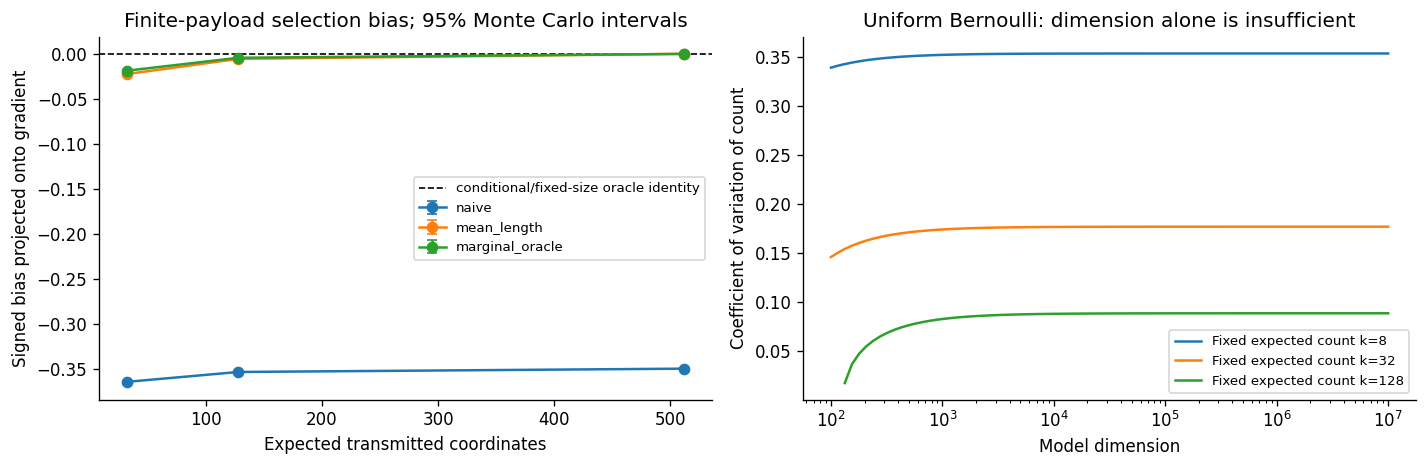

In [ ]:
def bias_diagnostic(g, k, target, cfg, seed=1907):
    local_cfg = replace(cfg, mean_success_target=target)
    deadline = deadline_for_k(k, local_cfg)
    pi = inclusion_probabilities(g, k, cfg.importance_uniform_mix)
    mean_den = float(delivery_probability(wire_bytes_for_count(k), cfg.nominal_snr, deadline, cfg))
    rng = np.random.default_rng(seed)
    batches = cfg.diagnostic_batches
    per_batch = max(8, math.ceil(cfg.diagnostic_draws/batches))
    derivative_batches, pbar_batches, second_moments = [], [], []
    g64 = np.asarray(g, np.float64)
    norm2 = float(g64@g64)
    if norm2 <= 1e-30: raise ValueError('Diagnostic gradient is zero')
    for b in range(batches):
        BUDGET.guard()
        mask = (rng.random((per_batch, len(g))) < pi).astype(np.float64)
        counts = mask.sum(axis=1)
        p = delivery_probability(wire_bytes_for_count(counts), cfg.nominal_snr, deadline, cfg)
        p_next = delivery_probability(wire_bytes_for_count(counts+1), cfg.nominal_snr, deadline, cfg)
        if np.any(p < cfg.numeric_probability_floor):
            raise FloatingPointError('Diagnostic encountered extreme inverse probabilities; inspect the regime explicitly')
        conditional_factor = p_next.mean() + (p-p_next)@mask/per_batch
        derivative_batches.append(conditional_factor)
        pbar_batches.append(float(p.mean()))
        qnorm2 = mask@(g64/pi)**2
        second_moments.append([float(np.mean(p*qnorm2)), float(np.mean(qnorm2/p))])
    factors = np.stack(derivative_batches)
    factor = factors.mean(axis=0)
    pbar = float(np.mean(pbar_batches))
    first = {'naive': g64*factor, 'mean_length': g64*factor/mean_den,
             'marginal_oracle': g64*factor/pbar}
    second = np.mean(second_moments, axis=0)
    rows = []
    for method, expected in first.items():
        bias = expected-g64
        denominator = 1.0 if method == 'naive' else mean_den if method == 'mean_length' else pbar
        per_den = np.ones(batches) if method == 'naive' else np.full(batches, mean_den) if method == 'mean_length' else np.array(pbar_batches)
        projections = np.sum((factors/per_den[:, None]-1)*(g64**2), axis=1)/norm2
        mc_halfwidth = float(stats.t.ppf(.975, batches-1)*np.std(projections, ddof=1)/math.sqrt(batches))
        rows.append({'k': k, 'target': target, 'method': method, 'source': 'Rao-Blackwell Monte Carlo',
                     'relative_bias_norm': float(np.linalg.norm(bias)/math.sqrt(norm2)),
                     'signed_projected_bias': float(bias@g64/norm2), 'projection_mc_halfwidth': mc_halfwidth,
                     'gradient_direction_cosine': float(expected@g64/(np.linalg.norm(expected)*math.sqrt(norm2))),
                     'second_moment_ratio': float(second[0]/denominator**2/norm2),
                     'mean_delivery_probability': pbar, 'payload_count_cv': float(np.sqrt(np.sum(pi*(1-pi)))/k),
                     'deadline_seconds': deadline, 'mc_draws': batches*per_batch})
    for method in ('conditional', 'fixed_k'):
        rows.append({'k': k, 'target': target, 'method': method, 'source': 'analytic under stated assumptions',
                     'relative_bias_norm': 0.0, 'signed_projected_bias': 0.0, 'projection_mc_halfwidth': 0.0,
                     'gradient_direction_cosine': 1.0,
                     'second_moment_ratio': float(second[1]/norm2) if method == 'conditional' else None,
                     'mean_delivery_probability': pbar if method == 'conditional' else mean_den,
                     'payload_count_cv': float(np.sqrt(np.sum(pi*(1-pi)))/k) if method == 'conditional' else 0.0,
                     'deadline_seconds': deadline, 'mc_draws': 0})
    return rows

def save_figure(fig, stem):
    fig.tight_layout()
    fig.savefig(STUDY/'figures'/f'{stem}.png', bbox_inches='tight')
    fig.savefig(STUDY/'figures'/f'{stem}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

DIAGNOSTICS = pd.DataFrame()
if CFG.run_diagnostics:
    model = FlatModel(DATA['d'], DATA['classes'], 'logistic', BACKEND, DEVICE)
    r = np.random.default_rng(883)
    first_subject = sorted(DATA['clients'])[0]
    ids = r.choice(DATA['clients'][first_subject], min(128, len(DATA['clients'][first_subject])), replace=False)
    gradient, _ = model.gradients(model.initial(17), DATA['X'][ids][None], DATA['y'][ids][None])
    counts = sorted({s['k'] for s in PLAN if s['family'] == 'main'})
    targets = [.35, .65, .9] if CFG.profile == 'paper' else [.65]
    diagnostic_identity = digest_obj({'data': DATA_ID, 'code': CODE_ID,
                                     'gradient': hashlib.sha256(gradient.tobytes()).hexdigest(),
                                     'draws': CFG.diagnostic_draws, 'batches': CFG.diagnostic_batches,
                                     'counts': counts, 'targets': targets})
    rows = []
    for target in targets:
        for k in counts:
            path = STUDY/'diagnostics'/f'{diagnostic_identity[:12]}_k{k}_p{target:.2f}.json'
            if path.exists():
                result = json.loads(path.read_text())
            else:
                result = bias_diagnostic(gradient[0], k, target, CFG)
                atomic_json(path, result)  # checkpoint each grid point
            rows.extend(result)
    DIAGNOSTICS = pd.DataFrame(rows)
    DIAGNOSTICS.to_csv(STUDY/'tables'/'bias_diagnostics.csv', index=False)
    display(DIAGNOSTICS[['k', 'target', 'method', 'relative_bias_norm', 'signed_projected_bias', 'projection_mc_halfwidth']])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for method in ('naive', 'mean_length', 'marginal_oracle'):
        subset = DIAGNOSTICS[(DIAGNOSTICS['target'] == .65) & (DIAGNOSTICS['method'] == method)].sort_values('k')
        axes[0].errorbar(subset['k'], subset['signed_projected_bias'], yerr=subset['projection_mc_halfwidth'],
                         marker='o', capsize=3, label=method)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1, label='conditional/fixed-size oracle identity')
    axes[0].set(xlabel='Expected transmitted coordinates', ylabel='Signed bias projected onto gradient',
                title='Finite-payload selection bias; 95% Monte Carlo intervals')
    axes[0].legend(fontsize=8)
    dims = np.unique(np.logspace(2, 7, 80).astype(int))
    for k in (8, 32, 128):
        valid = dims[dims >= k]
        axes[1].semilogx(valid, np.sqrt((1-k/valid)/k), label=f'Fixed expected count k={k}')
    axes[1].set(xlabel='Model dimension', ylabel='Coefficient of variation of count',
                title='Uniform Bernoulli: dimension alone is insufficient')
    axes[1].legend(fontsize=8)
    save_figure(fig, 'finite_payload_bias')


## 11. Runtime pilot and full resumable study
The pilot measures actual round time; it is not a hyperparameter search. It uses separate run identities and never contributes to paper tables. A pilot-derived time estimate is approximate—checkpoint/Drive I/O, CPU contention and Colab scheduling can dominate tiny models.

The full grid runs each optimizer trajectory separately. A pause stops scheduling so you can reconnect or change the per-call time limit. Run All resumes; completed/diverged runs are terminal and are not silently rerun. To try a different learning rate, change it in the configuration, creating a new study. Never select that rate using final-test performance.

The 48 default robustness fits (24 MLP, 24 correlated-channel) compare conditional correction against the fixed-size importance baseline in an MLP and in a correlated channel. They are focused checks, not a comprehensive reproduction of the cited papers. Optional `uniform_fixed_k` and `clipped_conditional` methods can be added to a **new frozen plan**, with the GPU ledger still enforced.


In [ ]:
PILOT_ROWS = []
if CFG.run_experiments:
    for architecture in ('logistic', 'mlp'):
        pilot_cfg = replace(CFG, rounds=4, eval_every=2, checkpoint_every=2,
                            max_run_wall_seconds=max(CFG.max_run_wall_seconds, 120))
        middle_k = sorted({p['k'] for p in PLAN})[len({p['k'] for p in PLAN})//2]
        spec = {'model': architecture, 'method': 'conditional', 'k': middle_k,
                'seed': 101, 'channel': 'iid', 'family': 'runtime_pilot'}
        pilot, folder = run_one(spec, DATA, pilot_cfg, STUDY/'pilot', CODE_ID)
        if pilot['status'] != 'completed':
            print('Pilot did not complete:', pilot['status'], pilot['error'])
            break
        seconds_per_round = pilot['meters']['compute_wall_seconds']/pilot['round']
        PILOT_ROWS.append({'model': architecture, 'measured_seconds_per_round': seconds_per_round})
    if PILOT_ROWS:
        pilot_df = pd.DataFrame(PILOT_ROWS)
        pilot_df.to_csv(STUDY/'tables'/'runtime_pilot.csv', index=False)
        estimates = dict(zip(pilot_df['model'], pilot_df['measured_seconds_per_round']))
        projected = sum(estimates.get(p['model'], max(estimates.values()))*CFG.rounds for p in PLAN)/3600
        print(f'Round-compute projection: {projected:.3f} wall hours, before I/O, diagnostics and probe fitting.')
        print(f'GPU ledger reserved so far: {BUDGET.used()/3600:.3f} hours; scheduling limit {CFG.gpu_limit_hours:.1f}.')

def collect_run_states(plan, data, cfg, runs_root, code_id):
    out = []
    for spec in plan:
        identity = run_identity(spec, data, cfg, code_id)
        folder = Path(runs_root)/identity[:20]
        # Reading a completed state for reporting is backend-independent; training resume is not.
        state = load_checkpoint(folder, identity, replace(cfg, strict_backend_resume=False))
        out.append((spec, state, folder))
    return out

if CFG.run_experiments:
    for index, spec in enumerate(PLAN, 1):
        try:
            BUDGET.guard()
            state, folder = run_one(spec, DATA, CFG, STUDY/'runs', CODE_ID)
        except BudgetExceeded as e:
            print(str(e)); break
        if state['status'].startswith('paused'):
            print(f'Scheduling paused at job {index}/{len(PLAN)}. Re-run this notebook to resume.'); break
        if index % 6 == 0:
            print(f'Progress: {index}/{len(PLAN)} planned fits processed.')

RUN_STATES = collect_run_states(PLAN, DATA, CFG, STUDY/'runs', CODE_ID)
status_rows = [{**spec, 'status': s['status'] if s else 'not_started', 'round': s['round'] if s else 0,
                'error': s['error'] if s else None, 'run_directory': folder.name}
               for spec, s, folder in RUN_STATES]
STATUS = pd.DataFrame(status_rows)
STATUS.to_csv(STUDY/'tables'/'run_status.csv', index=False)
display(STATUS.groupby(['family', 'status'], as_index=False).size())


logistic conditional            k= 128 seed=101 iid   : completed at round 4/4
mlp      conditional            k= 128 seed=101 iid   : completed at round 4/4
Round-compute projection: 0.355 wall hours, before I/O, diagnostics and probe fitting.
GPU ledger reserved so far: 0.246 hours; scheduling limit 9.0.
logistic naive                  k=  32 seed=11 iid   : completed at round 600/600
logistic mean_length            k=  32 seed=11 iid   : completed at round 600/600
logistic client_ema             k=  32 seed=11 iid   : completed at round 600/600
logistic conditional            k=  32 seed=11 iid   : completed at round 600/600
logistic estimated_conditional  k=  32 seed=11 iid   : completed at round 600/600
logistic fixed_k                k=  32 seed=11 iid   : completed at round 600/600
Progress: 6/264 planned fits processed.
logistic naive                  k= 128 seed=11 iid   : completed at round 600/600
logistic mean_length            k= 128 seed=11 iid   : completed at round 600/

,family,status,size
0,channel_robustness,completed,24
1,main,completed,216
2,mlp_robustness,completed,24


## 12. Learning curves and matched-cost comparisons
Validation curves use actual accumulated costs, including setup/probes. At a common byte or time budget, the comparison takes the **last observed validation score at or before that budget**—no interpolation from a future checkpoint. Comparisons require the same model, seed, channel and count, and all six main methods must complete. Missing/failed groups are reported, not silently treated as wins.

Final comparison intervals are paired across seeds. The 12 seeds capture training randomness (initialization, sampling and channel draws) only; the intervals do not reflect variation across subjects or datasets and do not justify sweeping significance claims. The number of subjects/rounds is not substituted for the number of independent training seeds. More seeds require a new frozen plan.


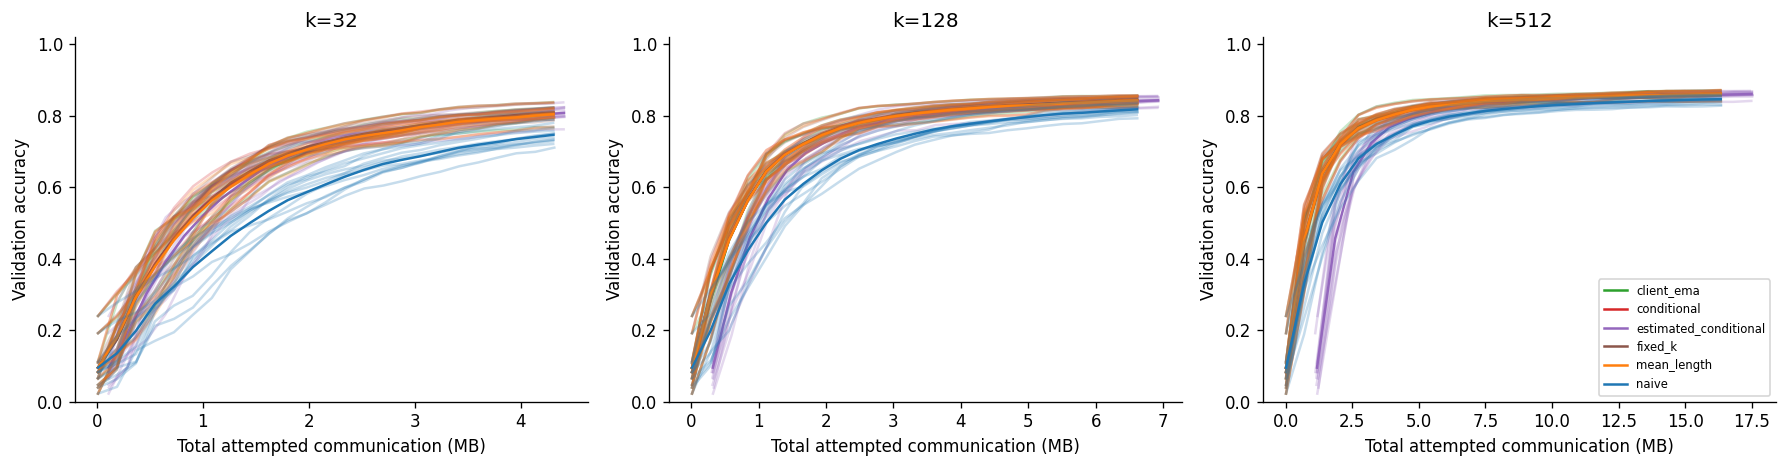

,model,channel,k,cost_metric,method,reference,n_paired_seeds,mean_difference,ci95_low,ci95_high
0,logistic,iid,32,sim_seconds,client_ema,fixed_k,12,-0.002433,-0.007921,0.003054
1,logistic,iid,32,sim_seconds,conditional,fixed_k,12,-0.002690,-0.007883,0.002504
2,logistic,iid,32,sim_seconds,estimated_conditional,fixed_k,12,-0.008709,-0.016841,-0.000577
3,logistic,iid,32,sim_seconds,mean_length,fixed_k,12,-0.004568,-0.010052,0.000916
4,logistic,iid,32,sim_seconds,naive,fixed_k,12,-0.062073,-0.069374,-0.054773
5,logistic,iid,32,total_wire_bytes,client_ema,fixed_k,12,-0.002988,-0.008789,0.002812
6,logistic,iid,32,total_wire_bytes,conditional,fixed_k,12,-0.004056,-0.010457,0.002346
7,logistic,iid,32,total_wire_bytes,estimated_conditional,fixed_k,12,-0.002433,-0.010695,0.005828
8,logistic,iid,32,total_wire_bytes,mean_length,fixed_k,12,-0.005593,-0.011269,0.000083
9,logistic,iid,32,total_wire_bytes,naive,fixed_k,12,-0.064635,-0.074448,-0.054821


In [ ]:
history_rows = []
for spec, state, _ in RUN_STATES:
    if state is not None:
        for record in state['history']:
            history_rows.append({**spec, **record, 'run_status': state['status']})
HISTORY = pd.DataFrame(history_rows)
if not HISTORY.empty:
    HISTORY.to_csv(STUDY/'tables'/'validation_history.csv', index=False)
    main = HISTORY[HISTORY['family'] == 'main']
    counts = sorted(main['k'].unique())
    if counts:
        fig, axes = plt.subplots(1, len(counts), figsize=(5*len(counts), 4), squeeze=False)
        palette = {method: plt.get_cmap('tab10')(i) for i, method in enumerate(METHODS)}
        for ax, k in zip(axes[0], counts):
            for method, rows in main[main['k'] == k].groupby('method'):
                # Plot each seed faintly; no false within-seed confidence bands.
                for seed, group in rows.groupby('seed'):
                    group = group.sort_values('round')
                    ax.plot(group['total_wire_bytes']/1e6, group['val_accuracy'], alpha=.25, color=palette[method])
                mean = rows.groupby('round', as_index=False).agg(total_wire_bytes=('total_wire_bytes','mean'),
                                                                  val_accuracy=('val_accuracy','mean'))
                ax.plot(mean['total_wire_bytes']/1e6, mean['val_accuracy'], label=method, color=palette[method])
            ax.set(title=f'k={k}', xlabel='Total attempted communication (MB)', ylabel='Validation accuracy', ylim=(0,1.02))
        axes[0][-1].legend(fontsize=7)
        save_figure(fig, 'validation_vs_total_bytes')

def matched_cost_table(run_states, cost, required_methods=METHODS):
    groups = defaultdict(dict)
    for spec, state, _ in run_states:
        if spec['family'] != 'main': continue
        key = (spec['model'], spec['channel'], spec['k'], spec['seed'])
        groups[key][spec['method']] = state
    rows, skipped = [], []
    for key, states in groups.items():
        if any(method not in states or states[method] is None or states[method]['status'] != 'completed'
               for method in required_methods):
            skipped.append({'group': list(key), 'reason': 'not all required methods completed'}); continue
        histories = {m: pd.DataFrame(states[m]['history']).sort_values('round') for m in required_methods}
        lower = max(h[cost].iloc[0] for h in histories.values())
        upper = min(h[cost].iloc[-1] for h in histories.values())
        if upper <= lower:
            skipped.append({'group': list(key), 'reason': 'no common cost range, including setup/probes'}); continue
        for method, h in histories.items():
            position = np.searchsorted(h[cost].to_numpy(), upper, side='right')-1
            observed = h.iloc[position]
            rows.append({'model': key[0], 'channel': key[1], 'k': key[2], 'seed': key[3],
                         'method': method, 'cost_metric': cost, 'common_budget': float(upper),
                         'observed_round': int(observed['round']), 'validation_accuracy': float(observed['val_accuracy']),
                         'validation_worst_subject': float(observed['val_worst_subject'])})
    return pd.DataFrame(rows), skipped

MATCHED = []
for cost in ('total_wire_bytes', 'uplink_bytes', 'sim_seconds'):
    table, skipped = matched_cost_table(RUN_STATES, cost)
    atomic_json(STUDY/'tables'/f'matched_{cost}_skipped.json', skipped)
    if not table.empty:
        table.to_csv(STUDY/'tables'/f'matched_{cost}.csv', index=False)
        MATCHED.append(table)

def paired_differences(frame, value_column, group_columns, reference='fixed_k'):
    output = []
    if frame.empty: return pd.DataFrame()
    for keys, block in frame.groupby(group_columns, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        pivot = block.pivot(index='seed', columns='method', values=value_column)
        if reference not in pivot: continue
        for method in pivot.columns:
            if method == reference: continue
            pairs = pivot[[method, reference]].dropna()
            delta = pairs[method]-pairs[reference]
            n = len(delta)
            if not n: continue
            halfwidth = float(stats.t.ppf(.975, n-1)*delta.std(ddof=1)/math.sqrt(n)) if n > 1 else None
            output.append({**dict(zip(group_columns, keys)), 'method': method, 'reference': reference,
                           'n_paired_seeds': n, 'mean_difference': float(delta.mean()),
                           'ci95_low': float(delta.mean()-halfwidth) if halfwidth is not None else None,
                           'ci95_high': float(delta.mean()+halfwidth) if halfwidth is not None else None})
    return pd.DataFrame(output)

if MATCHED:
    matched_all = pd.concat(MATCHED, ignore_index=True)
    paired = paired_differences(matched_all, 'validation_accuracy', ['model','channel','k','cost_metric'])
    paired.to_csv(STUDY/'tables'/'matched_cost_paired_differences.csv', index=False)
    display(paired)
else:
    print('No complete common-budget comparison yet. See run_status.csv and skipped-group records.')


## 13. Final held-out evaluation and failure reporting
The final test gate opens only when every planned fit is either completed or explicitly diverged. It evaluates the **last iterate at the fixed round budget**, not the most flattering test checkpoint. Validation-best weights are saved for inspection but are not used for the primary test table.

For subject holdout, `test_worst_subject_accuracy` refers to the worst **unseen test subject**, not the worst participating training client. The within-subject protocol instead measures held-out windows of participating clients. A single minimum is unstable, so per-subject accuracies and full confusion matrices are also exported.

Failed runs remain in `run_status.csv` and the summary. Paired comparisons state their available seed count; interpret them alongside failures, because comparing only successful methods can introduce survivorship bias. Accuracy improvements are not guaranteed by unbiasedness: report variance, convergence, and the fixed-size baseline even if the proposed method loses.


,family,model,channel,k,method,mean_test_accuracy,std_test_accuracy,mean_worst_subject_accuracy,completed_seeds,mean_uplink_bytes,mean_downlink_bytes,mean_sim_seconds
0,channel_robustness,logistic,markov,128,conditional,0.527380,0.060633,0.277630,12,3.470829e+06,3144888.0,29.605044
1,channel_robustness,logistic,markov,128,fixed_k,0.524634,0.052885,0.272620,12,3.469608e+06,3144888.0,29.605044
2,main,logistic,iid,32,client_ema,0.493553,0.059393,0.208593,12,1.165266e+06,3144888.0,12.479655
3,main,logistic,iid,32,conditional,0.492200,0.059639,0.207101,12,1.165213e+06,3144888.0,12.479655
4,main,logistic,iid,32,estimated_conditional,0.484678,0.059671,0.215130,12,1.264549e+06,3144888.0,13.024794
5,main,logistic,iid,32,fixed_k,0.499284,0.062664,0.202626,12,1.165608e+06,3144888.0,12.479655
6,main,logistic,iid,32,mean_length,0.491046,0.059842,0.199953,12,1.165292e+06,3144888.0,12.479655
7,main,logistic,iid,32,naive,0.446116,0.070202,0.154045,12,1.165667e+06,3144888.0,12.479655
8,main,logistic,iid,128,client_ema,0.535538,0.055819,0.267544,12,3.470881e+06,3144888.0,29.605044
9,main,logistic,iid,128,conditional,0.534304,0.055916,0.263161,12,3.471096e+06,3144888.0,29.605044


,family,model,channel,k,method,reference,n_paired_seeds,mean_difference,ci95_low,ci95_high
0,channel_robustness,logistic,markov,128,conditional,fixed_k,12,0.002746,-0.018186,0.023678
1,main,logistic,iid,32,client_ema,fixed_k,12,-0.005731,-0.015440,0.003979
2,main,logistic,iid,32,conditional,fixed_k,12,-0.007084,-0.017170,0.003003
3,main,logistic,iid,32,estimated_conditional,fixed_k,12,-0.014605,-0.024490,-0.004720
4,main,logistic,iid,32,mean_length,fixed_k,12,-0.008238,-0.017961,0.001486
5,main,logistic,iid,32,naive,fixed_k,12,-0.053168,-0.079322,-0.027014
6,main,logistic,iid,128,client_ema,fixed_k,12,0.002109,-0.003259,0.007477
7,main,logistic,iid,128,conditional,fixed_k,12,0.000876,-0.015148,0.016899
8,main,logistic,iid,128,estimated_conditional,fixed_k,12,-0.002905,-0.023021,0.017211
9,main,logistic,iid,128,mean_length,fixed_k,12,0.004218,-0.010998,0.019435


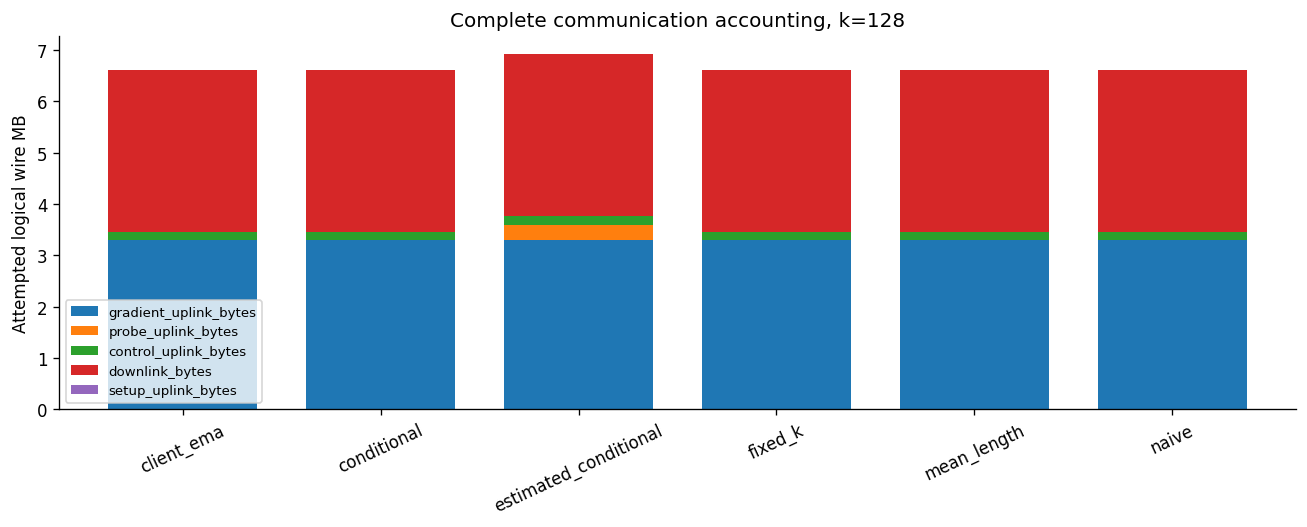

In [ ]:
TERMINAL = all(state is not None and state['status'] in {'completed', 'diverged'}
               for _, state, _ in RUN_STATES)
TEST_ROWS, SUBJECT_ROWS = [], []
if CFG.final_test and TERMINAL:
    # Opening this marker constitutes opening the final test; further tuning is a new exploratory study.
    marker = STUDY/'test_opened.json'
    if not marker.exists():
        atomic_json(marker, {'opened': utc_now(), 'plan_sha256': sha_file(plan_path),
                             'checkpoint_policy': 'last fixed-budget iterate'})
    for spec, state, folder in RUN_STATES:
        if state['status'] != 'completed': continue
        path = folder/'test_metrics.json'
        checkpoint_sha = hashlib.sha256(state['w'].tobytes()).hexdigest()
        if path.exists():
            test = json.loads(path.read_text())
            if test['weights_sha256'] != checkpoint_sha or test['data_id'] != DATA_ID:
                raise RuntimeError('Test result does not match the saved final model/data')
        else:
            model = FlatModel(DATA['d'], DATA['classes'], spec['model'])
            metrics = evaluate(model, state['w'], DATA, 'test')
            test = {'weights_sha256': checkpoint_sha, 'data_id': DATA_ID,
                    'evaluated': utc_now(), 'metrics': metrics, 'round': state['round']}
            atomic_json(path, test)
        m = test['metrics']
        TEST_ROWS.append({**spec, 'test_accuracy': m['accuracy'], 'test_loss': m['loss'],
                          'test_balanced_accuracy': m['balanced_accuracy'],
                          'test_worst_subject_accuracy': m['worst_subject_accuracy'],
                          'last_round': state['round'], 'validation_best_round': state['best_round'],
                          **state['meters'], 'deadline_seconds': state['deadline_seconds']})
        for subject, accuracy in m['per_subject'].items():
            SUBJECT_ROWS.append({**spec, 'subject': subject, 'test_accuracy': accuracy})
    TEST = pd.DataFrame(TEST_ROWS)
    SUBJECT_TEST = pd.DataFrame(SUBJECT_ROWS)
    TEST.to_csv(STUDY/'tables'/'final_test_metrics.csv', index=False)
    SUBJECT_TEST.to_csv(STUDY/'tables'/'per_subject_test_metrics.csv', index=False)
    if not TEST.empty:
        summary = TEST.groupby(['family','model','channel','k','method'], as_index=False).agg(
            mean_test_accuracy=('test_accuracy','mean'), std_test_accuracy=('test_accuracy','std'),
            mean_worst_subject_accuracy=('test_worst_subject_accuracy','mean'),
            completed_seeds=('seed','nunique'), mean_uplink_bytes=('uplink_bytes','mean'),
            mean_downlink_bytes=('downlink_bytes','mean'), mean_sim_seconds=('sim_seconds','mean'))
        summary.to_csv(STUDY/'tables'/'final_test_summary.csv', index=False)
        test_pairs = paired_differences(TEST, 'test_accuracy', ['family','model','channel','k'])
        test_pairs.to_csv(STUDY/'tables'/'final_test_paired_differences.csv', index=False)
        display(summary)
        display(test_pairs)
        main = TEST[TEST['family'] == 'main']
        focus_k = sorted(main['k'].unique())[len(main['k'].unique())//2]
        costs = main[main['k'] == focus_k].groupby('method')[
            ['gradient_uplink_bytes','probe_uplink_bytes','control_uplink_bytes','downlink_bytes']].mean()
        # Setup uplink is a separate residual, not silently omitted from the total.
        all_up = main[main['k'] == focus_k].groupby('method')['uplink_bytes'].mean()
        costs['setup_uplink_bytes'] = all_up-costs[['gradient_uplink_bytes','probe_uplink_bytes','control_uplink_bytes']].sum(axis=1)
        fig, ax = plt.subplots(figsize=(11, 4.5))
        (costs/1e6).plot.bar(stacked=True, ax=ax, width=.75)
        ax.set(title=f'Complete communication accounting, k={focus_k}', ylabel='Attempted logical wire MB', xlabel='')
        ax.tick_params(axis='x', rotation=25)
        ax.legend(fontsize=8)
        save_figure(fig, 'communication_accounting')
else:
    TEST = pd.DataFrame()
    print('Final test remains closed:', 'disabled by configuration' if not CFG.final_test else 'some planned runs are incomplete')


## 14. Research report, downloadable bundle, and resuming
The report records what actually ran; it does not assert the hypothesis succeeded. The ZIP includes this study's checkpoints, tables, plots, run/split manifests, a prepared-data snapshot and budget ledger, but excludes the source dataset archive. On Drive, keep the entire `TinyPayloadFL` folder. To restore elsewhere, extract the ZIP into a persistent output root and provide the same raw dataset (or allow UCI to download again); then use the same scientific configuration and code. The prepared-data snapshot is an audit artifact; preprocessing is checked again on startup.

**Important:** changing a method, learning rate, split or implementation starts a new study. Re-running an unchanged notebook resumes the existing one. A per-call timeout can be raised without changing its scientific identity. If a CUDA runtime is unavailable, you can report existing results on CPU by setting `run_experiments=False`; exact training continuation defaults to requiring the same backend.

Download links appear below. On Colab, the optional browser download line is commented so an unattended run does not launch a large download unexpectedly. Disconnect the GPU after exporting.


In [ ]:
completed = int((STATUS['status'] == 'completed').sum())
diverged = int((STATUS['status'] == 'diverged').sum())
pending = len(PLAN)-completed-diverged
report = f'''# Tiny-payload wireless federated learning — run report

Generated: {utc_now()}
Study: {STUDY_ID}
Data source: {CFG.data_source}
Split: {CFG.split_protocol}
Backend: {BACKEND_ID}
Code fingerprint: {CODE_ID}

## Completion
Planned fits: {len(PLAN)}; completed: {completed}; diverged: {diverged}; pending: {pending}.
Final test gate opened: {bool(CFG.final_test and TERMINAL)}.
GPU ledger reserved wall hours at export: {BUDGET.used()/3600:.4f}.
Synthetic software-test results are not evidence on UCI HAR.

## Interpretation
- The exact covariance identity and oracle correction are mathematical contracts, not claims of novel theorems.
- The large-gradient bias diagnostic uses Rao–Blackwell Monte Carlo; its projected-bias intervals measure simulation uncertainty only.
- Test metrics use the last fixed-budget model; no test-based model selection occurs in this notebook.
- The fixed-size importance baseline shares inclusion probabilities with random-length importance sampling.
- Oracle methods know the channel curve; estimated correction pays for probes and may be biased by estimation/flooring.
- The full JCDO scheduling optimizer and CA-Fed are not implemented or claimed as reproduced.
- Block-outage, reliable observed-state control, reliable downlink, nominal setup rate and fixed OFDMA bandwidth are explicit simulation assumptions.
- Wire bytes are logical attempted datagrams, not PHY coded symbols or energy. Slot time and downlink are also reported.
- Read failures alongside paired results; the 12 seeds cover training randomness only, not variation across subjects or datasets.
- Subject-holdout worst-subject accuracy is performance on unseen subjects; the optional row-block protocol is not a verified temporal split.

## Main files
tables/run_status.csv: every planned fit, including failures and incomplete runs.
tables/bias_diagnostics.csv: fixed-gradient selection-bias diagnostics, when enabled.
tables/validation_history.csv: learning curves with actual accumulated costs.
tables/matched_*: scores observed at or before a common cost budget.
tables/final_test_metrics.csv: held-out test results, only when the final test gate opens.
tables/per_subject_test_metrics.csv: individual-subject results.
runs/<id>/state_*.npz: three checkpoint generations with SHA-256 sidecars.

## Continue
Run the same notebook/configuration again. Completed runs are skipped; partial ones resume at the next uncommitted round.
Do not run two notebook processes against the same output root concurrently.
Do not reset the GPU ledger to evade the 10-hour experiment allowance.
'''
atomic_bytes(STUDY/'REPORT.md', report.encode())
atomic_json(STUDY/'data_manifest.json', DATA['manifest'])
atomic_json(STUDY/'completion.json', {'completed': completed, 'diverged': diverged, 'pending': pending,
                                    'test_opened': bool(CFG.final_test and TERMINAL), 'exported': utc_now()})

BUNDLE = ROOT/f'tiny_payload_fl_results_{STUDY_ID[:16]}.zip'
tmp_bundle = BUNDLE.with_suffix('.zip.tmp')
with zipfile.ZipFile(tmp_bundle, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=5) as z:
    for path in sorted(STUDY.rglob('*')):
        if path.is_file() and not path.name.endswith('.tmp'):
            z.write(path, path.relative_to(ROOT))
    z.write(ROOT/'gpu_budget.json', 'gpu_budget.json')
    z.write(DATA_CACHE, Path('data')/DATA_CACHE.name)
    z.write(DATA_CACHE.with_suffix('.json'), Path('data')/DATA_CACHE.with_suffix('.json').name)
os.replace(tmp_bundle, BUNDLE)
print(f'Exported {BUNDLE.name} ({BUNDLE.stat().st_size/1e6:.2f} MB)')
print(f'Complete: {completed}/{len(PLAN)} | diverged: {diverged} | pending: {pending}')
if IN_COLAB:
    from IPython.display import FileLink
    display(FileLink(str(BUNDLE)))
    # Optional explicit browser download:
    # from google.colab import files
    # files.download(str(BUNDLE))
else:
    print('Results:', BUNDLE)


Exported tiny_payload_fl_results_35e0fe8ed76f5167.zip (29.34 MB)
Complete: 264/264 | diverged: 0 | pending: 0


/content/drive/MyDrive/TinyPayloadFL_pamap2/tiny_payload_fl_results_35e0fe8ed76f5167.zip

## References and what they support
1. Zhang et al. (2023), [Joint Compression and Deadline Optimization for Wireless Federated Learning](https://arxiv.org/abs/2305.03969). The closest asymptotic compression/deadline model; the notebook isolates its mean-payload approximation and does not reproduce its joint optimizer.
2. Rodio et al. (2023), [Federated Learning under Heterogeneous and Correlated Client Availability](https://arxiv.org/abs/2301.04632). Motivation for participation-aware baselines and correlated-availability controls.
3. Sun et al. (2024), [Debiasing Federated Learning with Correlated Client Participation](https://arxiv.org/abs/2410.01209). Related participation debiasing; the EMA heuristic here is not a reimplementation of that method.
4. Reyes-Ortiz et al. (2013), [UCI Human Activity Recognition Using Smartphones](https://doi.org/10.24432/C54S4K), CC BY 4.0. 10,299 windows, 30 subjects, six activities and 561 features; official split separates subjects and windows overlap by 50%.
5. [PyTorch saving/loading guidance](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html). Checkpoint design motivation; this implementation uses portable NPZ/JSON state with no pickle deserialization.

**Remaining work for a submission:** independently audit novelty; analyze the practically relevant finite-payload regime; add a convergence argument if claiming a new optimizer; compare against full literature implementations where the claim requires them; and report failure/variance cases. A runnable notebook is an experimental foundation, not an acceptance guarantee.
